In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
file_name = file_path = '/content/drive/MyDrive/Colab Notebooks/Warfarin.csv'

df = pd.read_csv(file_name)

df

Mounted at /content/drive


,PharmGKB Subject ID,PharmGKB Sample ID,Project Site,Gender,Race (Reported),Race (OMB),Ethnicity (Reported),Ethnicity (OMB),Age,Height (cm),...,VKORC1 QC genotype: -4451 C>A (861); Chr16:31018002; rs17880887; A/C,CYP2C9 consensus,VKORC1 -1639 consensus,VKORC1 497 consensus,VKORC1 1173 consensus,VKORC1 1542 consensus,VKORC1 3730 consensus,VKORC1 2255 consensus,VKORC1 -4451 consensus,Comments regarding Project Site Dataset
0,PA135312261,PA135312629,1,male,White,White,not Hispanic or Latino,not Hispanic or Latino,60 - 69,193.04,...,NaN,*1/*1,A/G,G/T,NaN,C/G,A/G,NaN,NaN,Project 1:
1,PA135312262,PA135312630,1,female,White,White,not Hispanic or Latino,not Hispanic or Latino,50 - 59,176.53,...,C/C,*1/*1,A/A,G/T,T/T,C/C,G/G,T/T,C/C,Warfarin Therapeutic Dose Definition:
2,PA135312263,PA135312631,1,female,White,White,not Hispanic or Latino,not Hispanic or Latino,40 - 49,162.56,...,NaN,*1/*1,G/G,T/T,NaN,G/G,A/G,NaN,NaN,The dose (unchanged for 6 days) that yielded a...
3,PA135312264,PA135312632,1,male,White,White,not Hispanic or Latino,not Hispanic or Latino,60 - 69,182.24,...,NaN,*1/*1,A/G,G/T,NaN,C/G,G/G,NaN,NaN,NaN
4,PA135312265,PA135312633,1,male,White,White,not Hispanic or Latino,not Hispanic or Latino,50 - 59,167.64,...,NaN,*1/*3,A/G,T/T,NaN,C/G,A/G,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5695,PA152407681,PA152407969,21,male,White,White,not Hispanic or Latino,not Hispanic or Latino,20 - 29,185.42,...,NaN,*1/*1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5696,PA152407682,PA152407970,21,female,White,White,not Hispanic or Latino,not Hispanic or Latino,70 - 79,160.02,...,NaN,*1/*3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5697,PA152407683,PA152407971,21,male,White,White,not Hispanic or Latino,not Hispanic or Latino,60 - 69,187.96,...,NaN,*1/*1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5698,PA152407684,PA152407972,21,male,White,White,not Hispanic or Latino,not Hispanic or Latino,60 - 69,177.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **Multi-stage preprocessing**

**1. Splitting the data into 4 main groups based on the “Race” column**

**2. Missing data imputation strategies**

**3. Data encoding**





In [ ]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OrdinalEncoder

import warnings
warnings.filterwarnings('ignore')

print("🌟 1. Starting Multi-Track Clinical Data Preprocessing...\n")

# ==========================================
# Step 1: Extracting raw data and basic cleaning
# ==========================================
dg = df[
    [
        "Race (OMB)", "Age", "Weight (kg)", "Height (cm)", "Gender",
        "Amiodarone (Cordarone)", "Aspirin", "Simvastatin (Zocor)",
        'Acetaminophen or Paracetamol (Tylenol)',
        'Was Dose of Acetaminophen or Paracetamol (Tylenol) >1300mg/day',
        'Atorvastatin (Lipitor)', 'Fluvastatin (Lescol)', 'Lovastatin (Mevacor)',
        'Pravastatin (Pravachol)', 'Rosuvastatin (Crestor)', 'Cerivastatin (Baycol)',
        'Carbamazepine (Tegretol)', 'Phenytoin (Dilantin)', 'Rifampin or Rifampicin',
        'Sulfonamide Antibiotics', 'Macrolide Antibiotics', 'Anti-fungal Azoles',
        'Herbal Medications, Vitamins, Supplements', 'Diabetes',
        "Valve Replacement", "Congestive Heart Failure and/or Cardiomyopathy",
        "INR on Reported Therapeutic Dose of Warfarin", "Therapeutic Dose of Warfarin",
        "CYP2C9 consensus", "VKORC1 -1639 consensus", "VKORC1 497 consensus",
        "VKORC1 1173 consensus", "VKORC1 1542 consensus", "VKORC1 3730 consensus",
        "VKORC1 2255 consensus", "VKORC1 -4451 consensus"
    ]
].copy()

# 1.1 Complex VKORC1 processing (LD-based algorithm)
def impute_vkorc1(row):
    race_excluded = row['Race (OMB)'] in ['Black or African American', 'Unknown']
    if pd.notna(row['VKORC1 -1639 consensus']):
        return row['VKORC1 -1639 consensus']
    if not race_excluded:
        if row['VKORC1 2255 consensus'] == 'C/C': return 'G/G'
        elif row['VKORC1 2255 consensus'] == 'T/T': return 'A/A'
        elif row['VKORC1 2255 consensus'] == 'C/T': return 'A/G'
    if row['VKORC1 1173 consensus'] == 'C/C': return 'G/G'
    elif row['VKORC1 1173 consensus'] == 'T/T': return 'A/A'
    elif row['VKORC1 1173 consensus'] == 'C/T': return 'A/G'
    if not race_excluded:
        if row['VKORC1 1542 consensus'] == 'G/G': return 'G/G'
        elif row['VKORC1 1542 consensus'] == 'C/C': return 'A/A'
        elif row['VKORC1 1542 consensus'] == 'C/G': return 'A/G'
    return "Missing"

dg['VKORC1 -1639 consensus'] = dg.apply(impute_vkorc1, axis=1)

# Dropping the secondary genetic columns used for the imputation
cols_to_drop = [
    'VKORC1 497 consensus', 'VKORC1 1173 consensus', 'VKORC1 1542 consensus',
    'VKORC1 3730 consensus', 'VKORC1 2255 consensus', 'VKORC1 -4451 consensus'
]
if 'Cerivastatin (Baycol)' in dg.columns:
    cols_to_drop.append('Cerivastatin (Baycol)')

dg.drop(columns=cols_to_drop, inplace=True, errors='ignore')
dg.dropna(subset=['Therapeutic Dose of Warfarin'], inplace=True)

# 1.2 Age and gender cleaning
age_map = {'10 - 19': 15, '20 - 29': 25, '30 - 39': 35, '40 - 49': 45, '50 - 59': 55, '60 - 69': 65, '70 - 79': 75, '80 - 89': 85, '90+': 95}
dg['Age'] = dg['Age'].map(age_map)
dg['Gender'] = dg['Gender'].map({'male': 0, 'female': 1}) # NaN values are left as NaN to be handled by MICE


# ==========================================
# Step 2: Splitting the data by race (The Core Split)
# ==========================================
white_df = dg[dg["Race (OMB)"] == "White"].drop(columns=["Race (OMB)"])
asian_df = dg[dg["Race (OMB)"] == "Asian"].drop(columns=["Race (OMB)"])
black_df = dg[dg["Race (OMB)"] == "Black or African American"].drop(columns=["Race (OMB)"])
unknown_df = dg[dg["Race (OMB)"] == "Unknown"].drop(columns=["Race (OMB)"])

# ==========================================
# Step 3: Race-specific smart imputation function
# ==========================================
# List of all binary variables (diseases and medications)
binary_cols = [
    'Gender', 'Amiodarone (Cordarone)', 'Aspirin', 'Simvastatin (Zocor)',
    'Acetaminophen or Paracetamol (Tylenol)', 'Was Dose of Acetaminophen or Paracetamol (Tylenol) >1300mg/day',
    'Atorvastatin (Lipitor)', 'Fluvastatin (Lescol)', 'Lovastatin (Mevacor)',
    'Pravastatin (Pravachol)', 'Rosuvastatin (Crestor)', 'Carbamazepine (Tegretol)',
    'Phenytoin (Dilantin)', 'Rifampin or Rifampicin', 'Sulfonamide Antibiotics',
    'Macrolide Antibiotics', 'Anti-fungal Azoles', 'Herbal Medications, Vitamins, Supplements',
    'Diabetes', 'Valve Replacement', 'Congestive Heart Failure and/or Cardiomyopathy'
]

categorical_genes = ['CYP2C9 consensus', 'VKORC1 -1639 consensus']

def process_race_dataset(df_race, race_name):
    print(f"\n🔄 Processing {race_name} Dataset ({len(df_race)} patients)...")
    df_clean = df_race.copy()

    # 1. Applying the "imputation rule": if a medication/disease is missing more than 40%, fill with 0
    zero_filled_cols = []
    for col in binary_cols:
        if col in df_clean.columns:
            missing_pct = df_clean[col].isna().mean()
            if missing_pct >= 0.40:
                df_clean[col].fillna(0, inplace=True)
                zero_filled_cols.append(col)

    if zero_filled_cols:
        print(f"   -> Hard-coded to 0 (Missing > 40%): {len(zero_filled_cols)} features (e.g., {zero_filled_cols[0]})")
    else:
        print("   -> No features exceeded 40% missingness. Proceeding to MICE directly.")

    # 2. Converting genes to numeric values to facilitate MICE
    ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
    df_clean[categorical_genes] = ord_enc.fit_transform(df_clean[categorical_genes])

    # 3. Applying MICE for the remaining data (age, weight, height, INR, and genes/medications with low missingness)
    print("   -> Running MICE for remaining missing values...")
    imputer = IterativeImputer(max_iter=15, random_state=42)
    df_imputed = pd.DataFrame(imputer.fit_transform(df_clean), columns=df_clean.columns, index=df_clean.index)

    # 4. Rounding binary variables, genes, and age to integers (0, 1, 2...)
    cols_to_round = binary_cols + categorical_genes + ['Age']
    for col in cols_to_round:
        if col in df_imputed.columns:
            # Clip binary variables between 0 and 1 and round in case MICE goes out of range
            if col in binary_cols:
                df_imputed[col] = np.clip(np.round(df_imputed[col]), 0, 1)
            else:
                df_imputed[col] = np.round(df_imputed[col])

            df_imputed[col] = df_imputed[col].astype(int)

    print(f"   ✅ {race_name} Processing Complete!")
    return df_imputed

# ==========================================
# Step 4: Processing each dataset separately
# ==========================================
white_ready = process_race_dataset(white_df, "White")
asian_ready = process_race_dataset(asian_df, "Asian")
black_ready = process_race_dataset(black_df, "Black")
unknown_ready = process_race_dataset(unknown_df, "Unknown")

print("\n" + "="*50)
print("🎉 All Datasets are Ready for Modeling! Shapes:")
print(f" - White Dataset  : {white_ready.shape}")
print(f" - Asian Dataset  : {asian_ready.shape}")
print(f" - Black Dataset  : {black_ready.shape}")
print(f" - Unknown Dataset: {unknown_ready.shape}")
print("="*50)

🌟 1. Starting Multi-Track Clinical Data Preprocessing...


🔄 Processing White Dataset (2969 patients)...
   -> Hard-coded to 0 (Missing > 40%): 14 features (e.g., Acetaminophen or Paracetamol (Tylenol))
   -> Running MICE for remaining missing values...
   ✅ White Processing Complete!

🔄 Processing Asian Dataset (1619 patients)...
   -> Hard-coded to 0 (Missing > 40%): 18 features (e.g., Amiodarone (Cordarone))
   -> Running MICE for remaining missing values...
   ✅ Asian Processing Complete!

🔄 Processing Black Dataset (462 patients)...
   -> Hard-coded to 0 (Missing > 40%): 1 features (e.g., Was Dose of Acetaminophen or Paracetamol (Tylenol) >1300mg/day)
   -> Running MICE for remaining missing values...
   ✅ Black Processing Complete!

🔄 Processing Unknown Dataset (478 patients)...
   -> Hard-coded to 0 (Missing > 40%): 19 features (e.g., Aspirin)
   -> Running MICE for remaining missing values...
   ✅ Unknown Processing Complete!

🎉 All Datasets are Ready for Modeling! Shapes:
 - W

# **Exploratory Data Analysis (EDA)**

**Normal distribution**

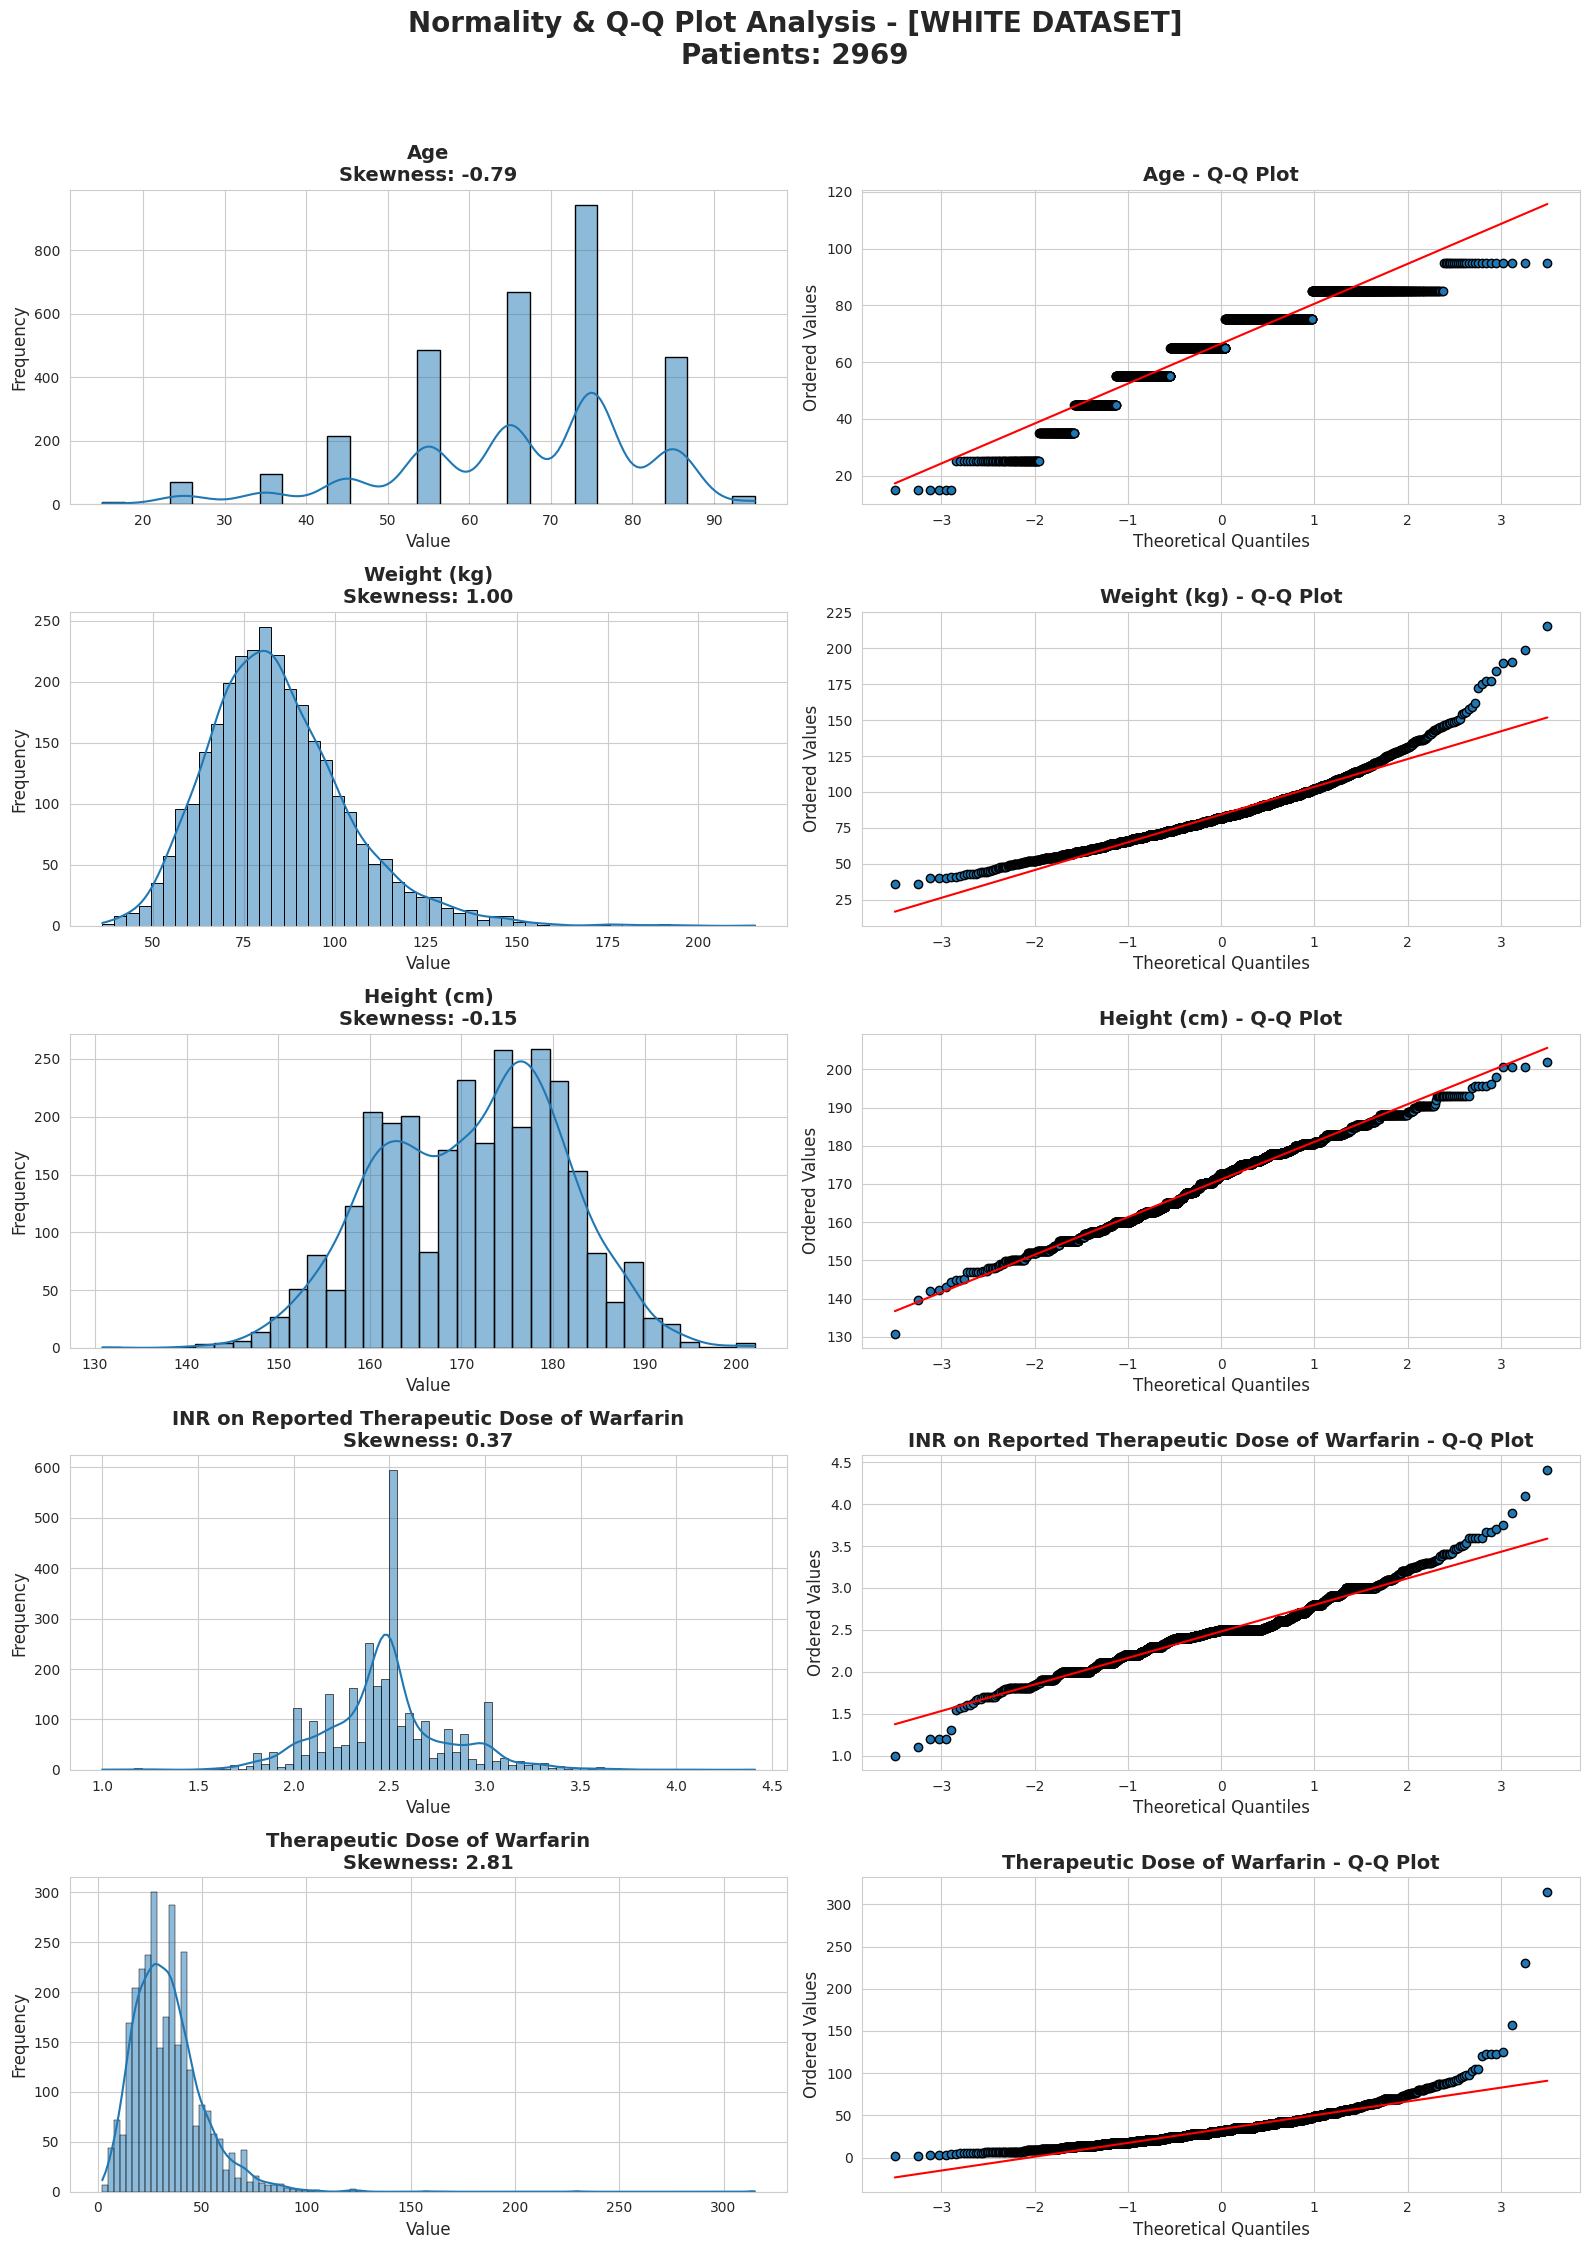

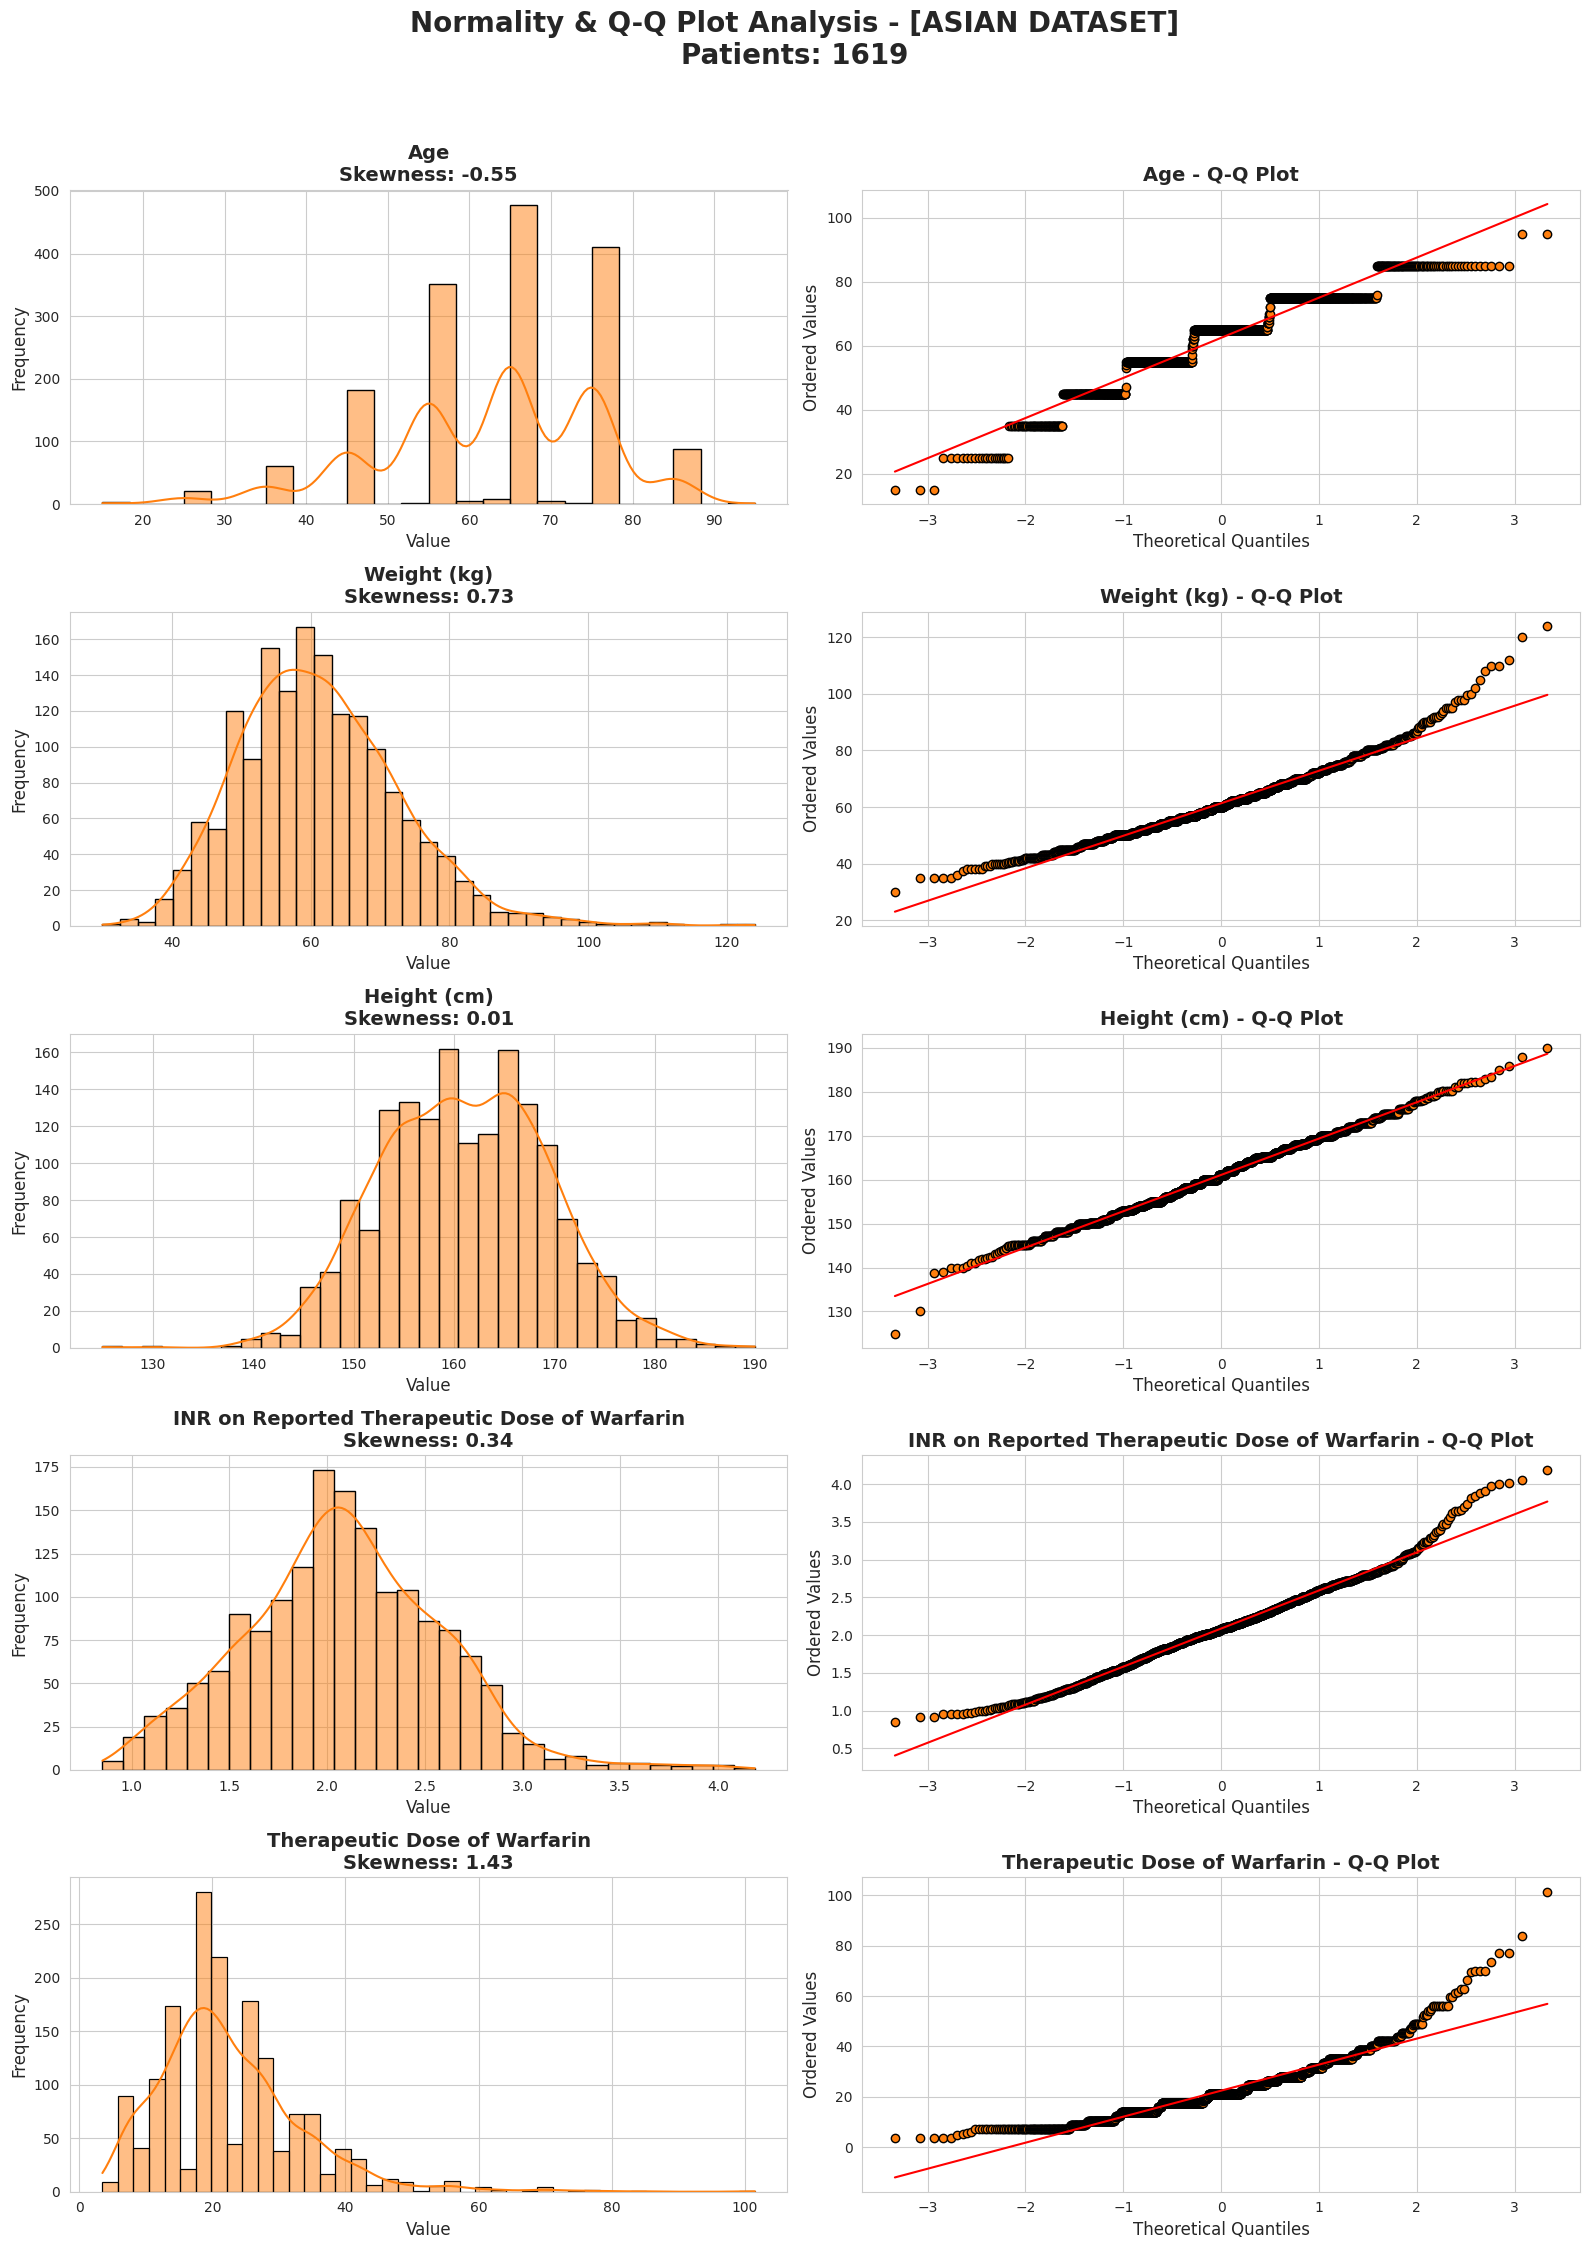

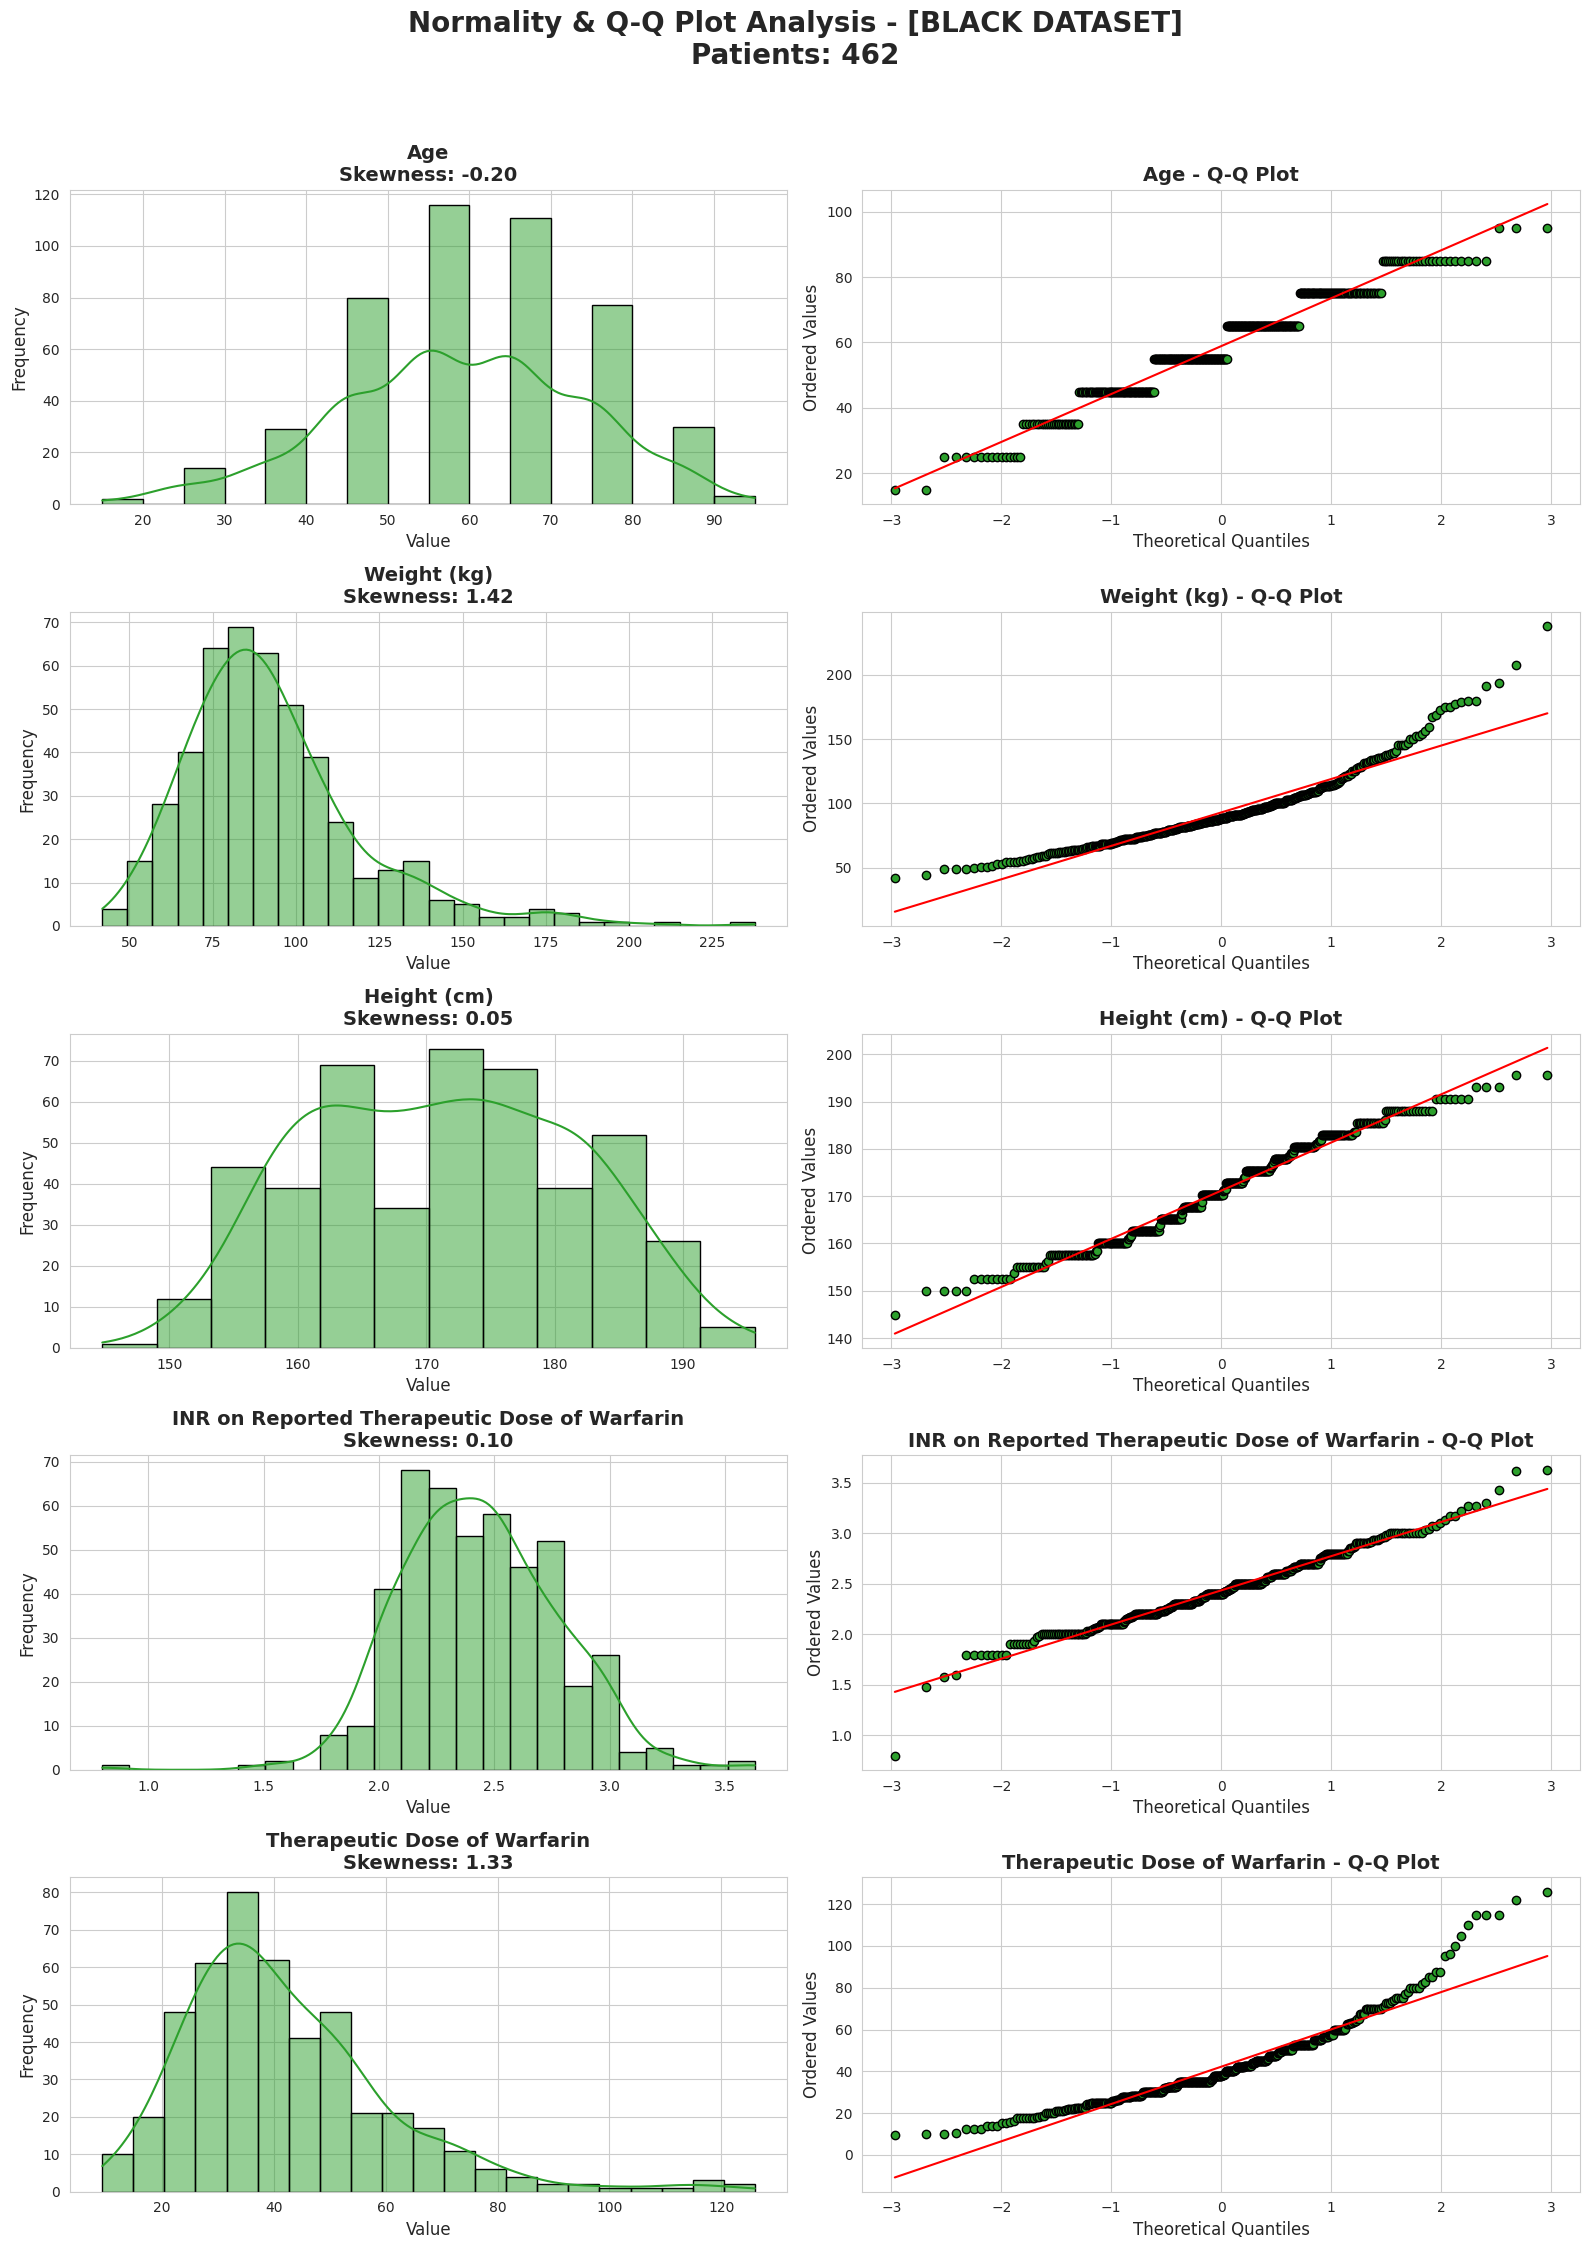

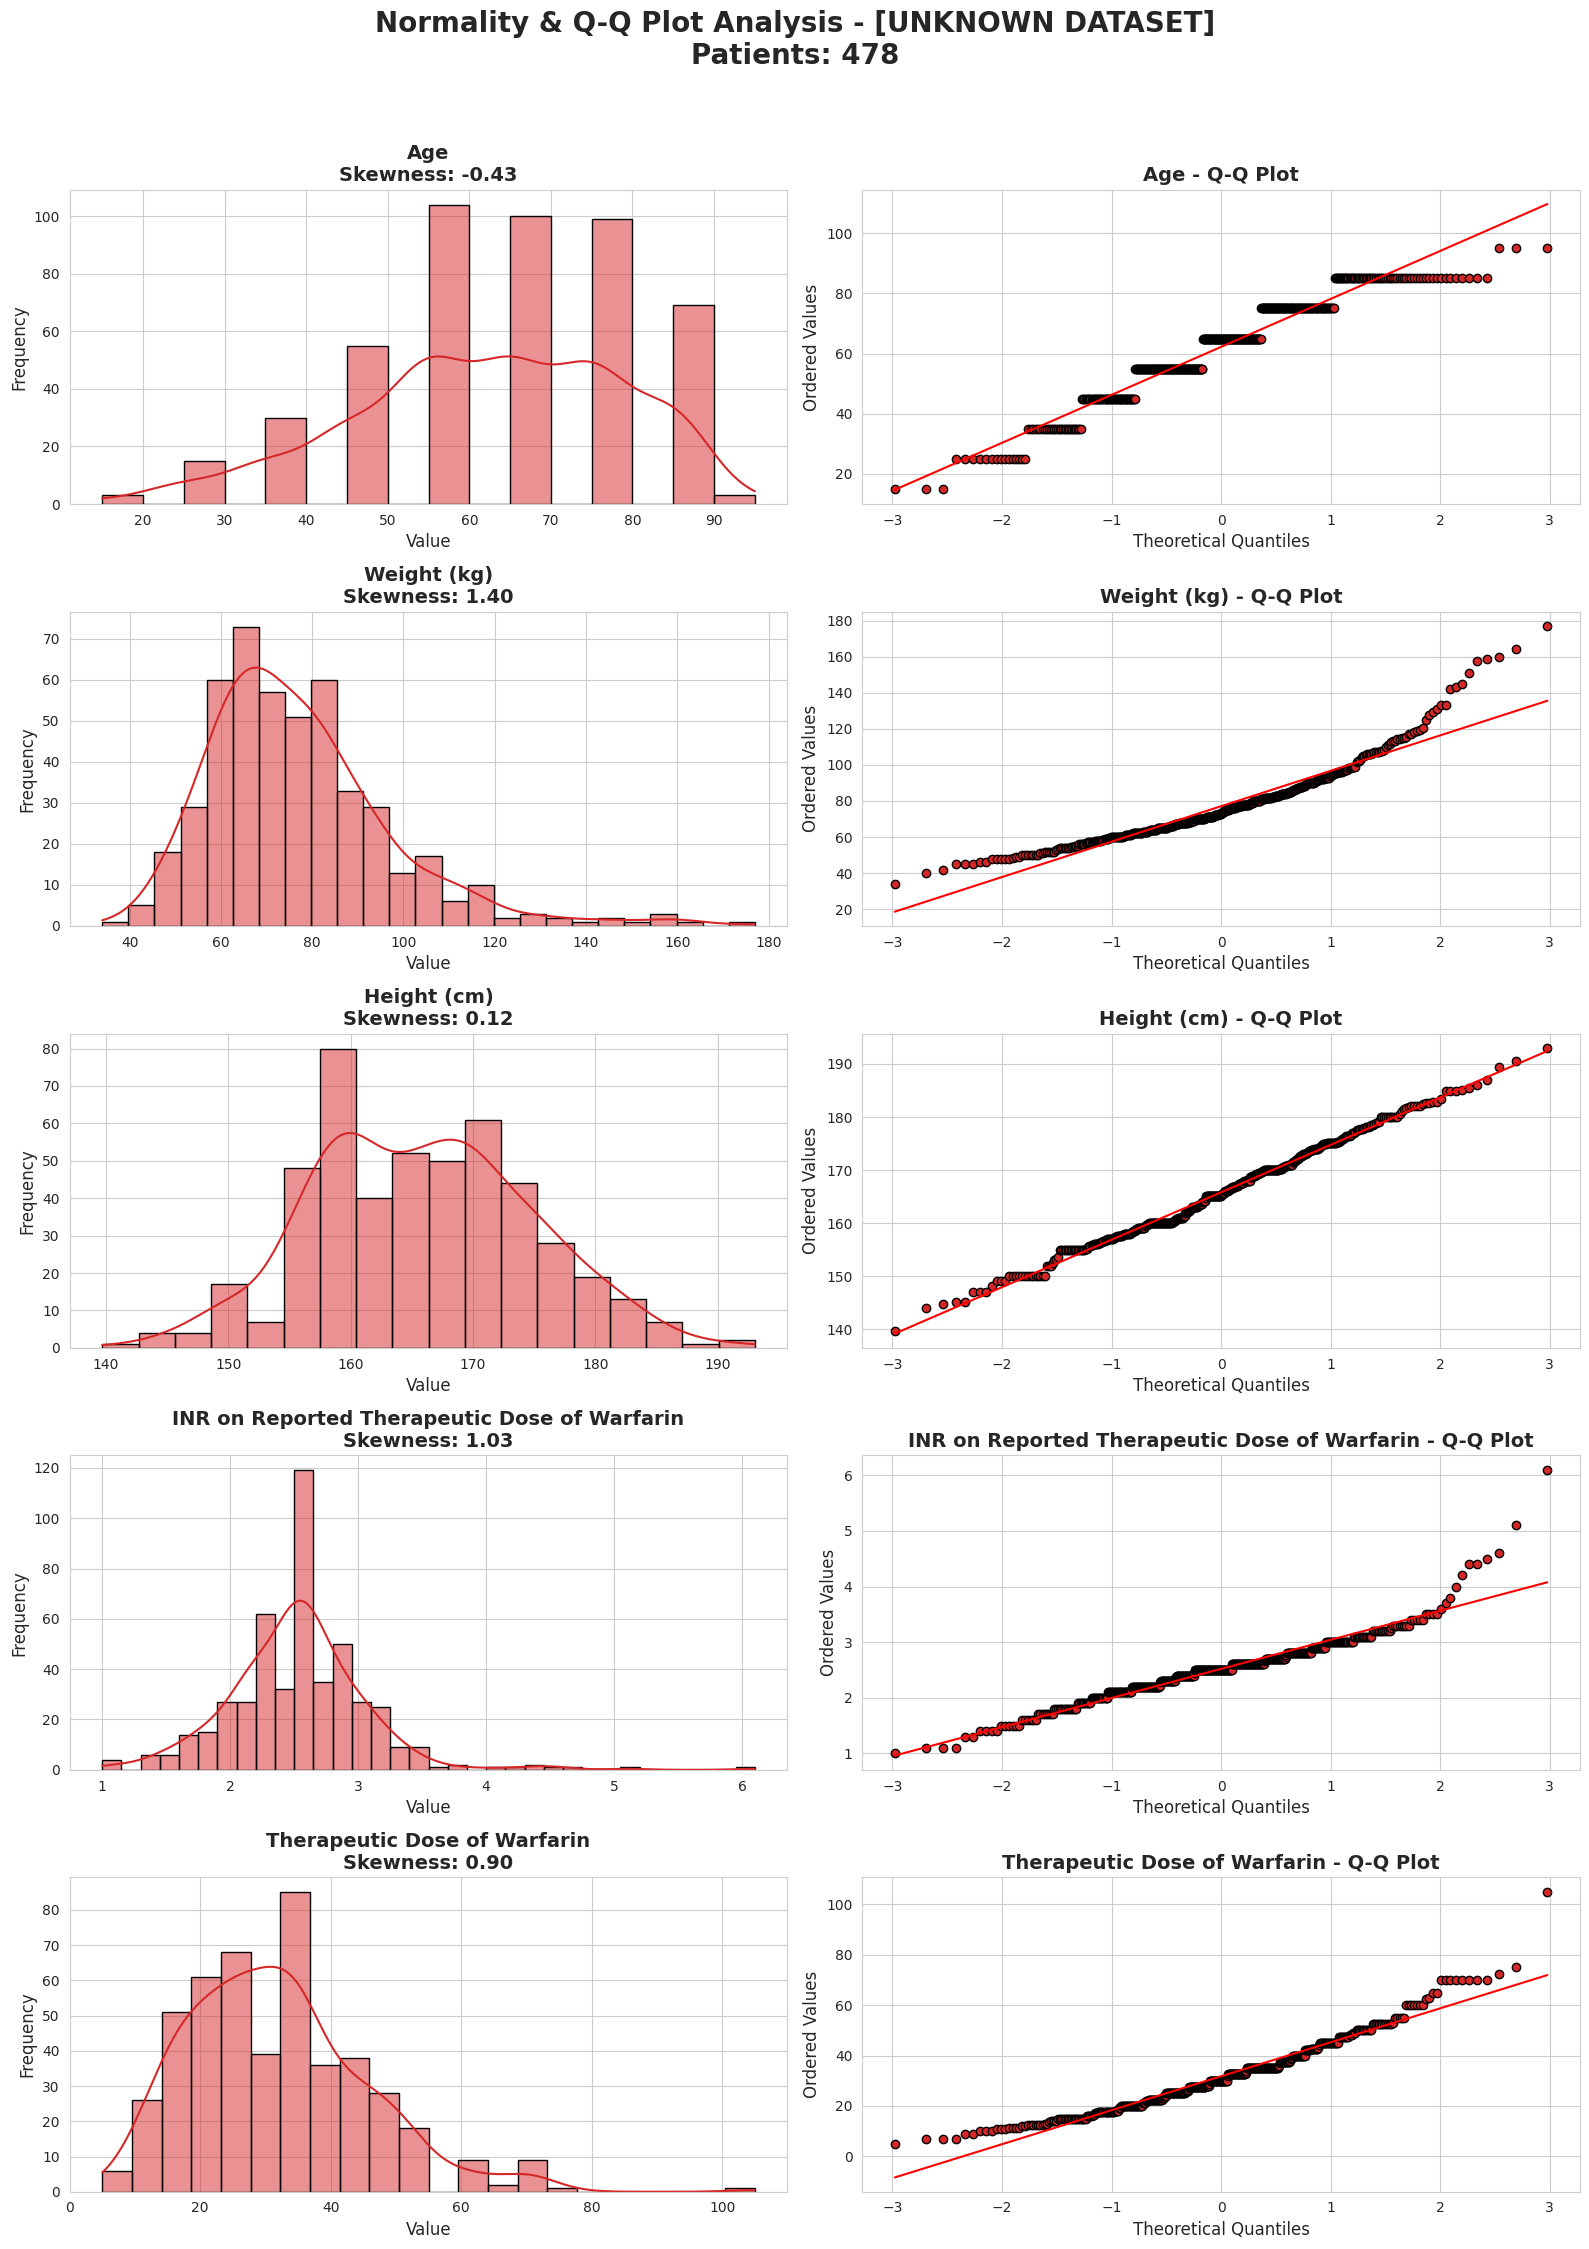

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Identifying continuous numerical columns
numerical_cols = [
    'Age',
    'Weight (kg)',
    'Height (cm)',
    'INR on Reported Therapeutic Dose of Warfarin',
    'Therapeutic Dose of Warfarin'
]

# Dictionary containing the ready datasets for each race and custom colors for visual distinction
datasets = {
    'White': {'data': white_ready, 'color': '#1f77b4'},
    'Asian': {'data': asian_ready, 'color': '#ff7f0e'},
    'Black': {'data': black_ready, 'color': '#2ca02c'},
    'Unknown': {'data': unknown_ready, 'color': '#d62728'}
}

sns.set_style("whitegrid") # Gridded background to make reading easier

# 2. Main loop to create a separate figure panel for each race
for race_name, info in datasets.items():
    df_race = info['data']
    race_color = info['color']

    # Setting up a tall Figure to hold 5 rows for each race
    fig = plt.figure(figsize=(16, 22))
    fig.suptitle(f'Normality & Q-Q Plot Analysis - [{race_name.upper()} DATASET]\nPatients: {len(df_race)}',
                 fontsize=20, fontweight='bold', y=1.02)

    # 3. Inner loop to plot each column within the current race
    for i, col in enumerate(numerical_cols):

        # Check that the column exists to avoid errors
        if col not in df_race.columns:
            continue

        # Calculating skewness
        skew_val = df_race[col].skew()

        # --- First plot: Histogram with KDE (frequency distribution) ---
        ax1 = plt.subplot(len(numerical_cols), 2, i*2 + 1)
        sns.histplot(df_race[col], kde=True, color=race_color, edgecolor='black', ax=ax1)
        ax1.set_title(f'{col}\nSkewness: {skew_val:.2f}', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Value', fontsize=12)
        ax1.set_ylabel('Frequency', fontsize=12)

        # --- Second plot: Q-Q Plot (normality test) ---
        ax2 = plt.subplot(len(numerical_cols), 2, i*2 + 2)
        stats.probplot(df_race[col], dist="norm", plot=ax2)
        ax2.set_title(f'{col} - Q-Q Plot', fontsize=14, fontweight='bold')
        ax2.get_lines()[0].set_markerfacecolor(race_color) # Color the points with the race color
        ax2.get_lines()[0].set_markeredgecolor('black')
        ax2.set_xlabel('Theoretical Quantiles', fontsize=12)
        ax2.set_ylabel('Ordered Values', fontsize=12)

    plt.tight_layout()
    plt.show()
    print("\n" + "="*80 + "\n") # Separator between each race

**Outliers**

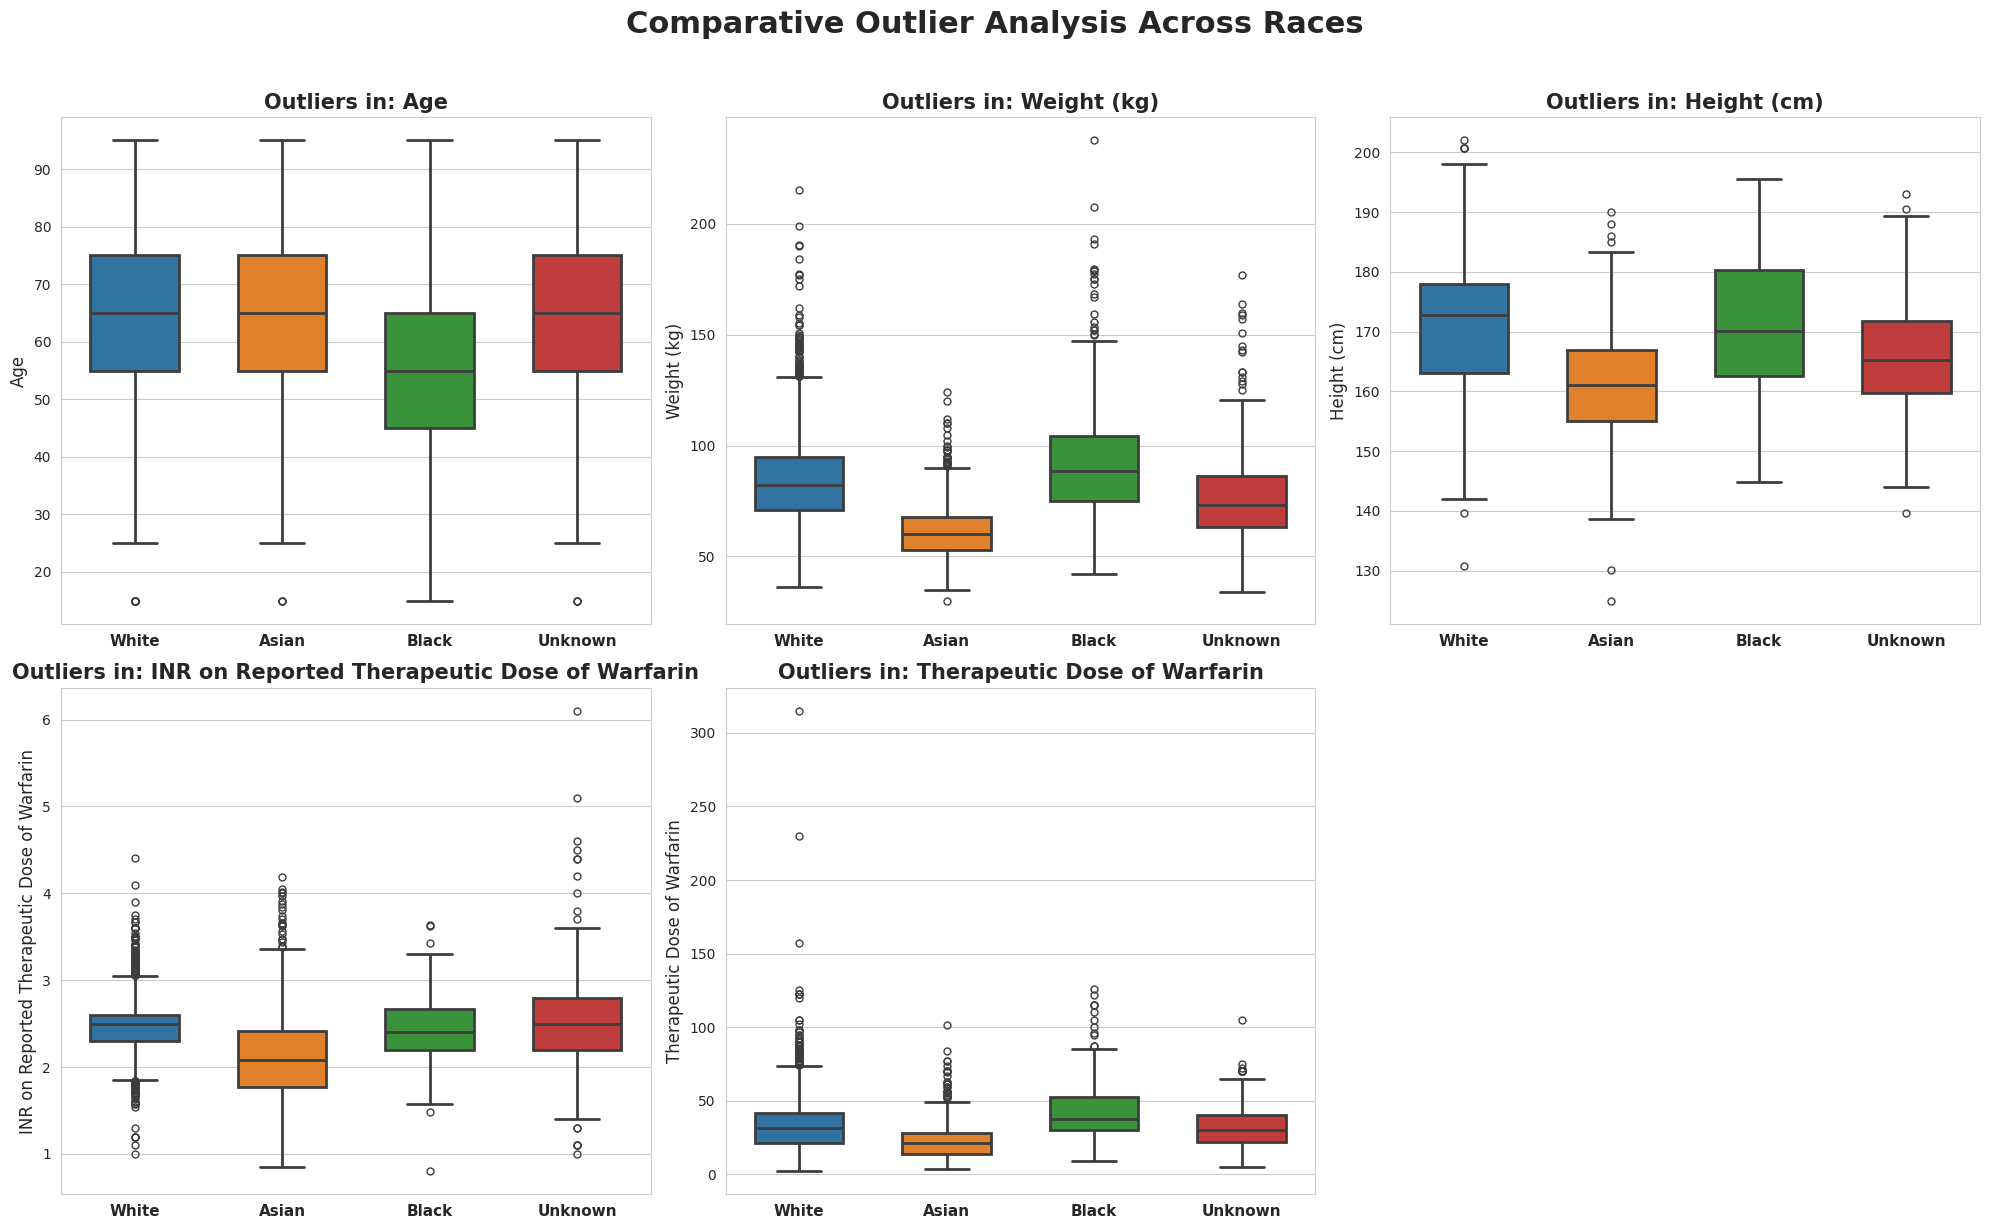

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Identifying numerical columns
numerical_cols = [
    'Age',
    'Weight (kg)',
    'Height (cm)',
    'INR on Reported Therapeutic Dose of Warfarin',
    'Therapeutic Dose of Warfarin'
]

# Combining the data into a single temporary DataFrame for plotting and comparison purposes only
combined_eda_df = pd.DataFrame()
datasets = {
    'White': white_ready,
    'Asian': asian_ready,
    'Black': black_ready,
    'Unknown': unknown_ready
}
colors = {'White': '#1f77b4', 'Asian': '#ff7f0e', 'Black': '#2ca02c', 'Unknown': '#d62728'}

for name, df in datasets.items():
    temp_df = df.copy()
    temp_df['Race'] = name
    combined_eda_df = pd.concat([combined_eda_df, temp_df])

# 2. Preparing the plot panel
plt.figure(figsize=(20, 12))  # Large size to accommodate the plots
sns.set_style("whitegrid")    # Gridded background to make reading values easier
plt.suptitle('Comparative Outlier Analysis Across Races', fontsize=22, fontweight='bold', y=1.02)

# 3. Loop to draw a comparative boxplot for each column
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)  # Dividing the screen into 2 rows and 3 columns

    # Check that the column exists to avoid errors
    if col not in combined_eda_df.columns:
        continue

    # Drawing side-by-side boxplots by race
    sns.boxplot(x='Race', y=col, data=combined_eda_df, palette=colors, width=0.6, linewidth=2, fliersize=5)

    # Visual improvements
    plt.title(f'Outliers in: {col}', fontsize=15, fontweight='bold')
    plt.ylabel(col, fontsize=12)
    plt.xlabel('') # Hiding the 'Race' label below for visual aesthetics
    plt.xticks(fontsize=11, fontweight='bold')

plt.tight_layout() # Automatically adjusting spacing between plots
plt.show()

**Splitting and transforming the data**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
import numpy as np
import pandas as pd

print("🚀 Starting Advanced Data Preprocessing (Leakage-Free)...\n")

# Collecting the datasets into a dictionary to make looping easier
datasets_ready = {
    'White': white_ready,
    'Asian': asian_ready,
    'Black': black_ready,
    'Unknown': unknown_ready
}

# Continuous columns that need RobustScaler applied
continuous_cols = [
    'Age',
    'Weight (kg)',
    'Height (cm)',
    'INR on Reported Therapeutic Dose of Warfarin'
]

# Empty dictionary to store model-ready data for each race
model_ready_data = {}

for race_name, df in datasets_ready.items():
    print(f"⚙️ Processing {race_name} Dataset...")

    # 1. Separating features (X) from the target (y)
    X = df.drop(columns=['Therapeutic Dose of Warfarin']).copy()
    y = df['Therapeutic Dose of Warfarin'].copy()

    # 2. Mandatory step 1: Logarithmic transform for dose (for all races)
    y_log = np.log1p(y)

    # 3. Mandatory step 2: Logarithmic transform for weight (only for White and Black)
    if race_name in ['White', 'Black']:
        X['Weight (kg)'] = np.log1p(X['Weight (kg)'])
        print(f"   -> Applied Log-Transform to Weight for {race_name}")

    # 4. Safeguard against data leakage: Train/Test split before standardization
    X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

    # 5. ColumnTransformer setup: RobustScaler is applied only to continuous columns
    # 'passthrough' means: leave the other columns (genes, medications) as they are
    preprocessor = ColumnTransformer(
        transformers=[
            ('num_scaler', RobustScaler(), continuous_cols)
        ],
        remainder='passthrough'
    )

    # Getting the new column order after the transformation
    other_cols = [col for col in X.columns if col not in continuous_cols]
    final_columns = continuous_cols + other_cols

    # 6. Mandatory step 3: Applying standardization (Fit only on training data, Transform on test data)
    X_train_scaled = pd.DataFrame(preprocessor.fit_transform(X_train), columns=final_columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(preprocessor.transform(X_test), columns=final_columns, index=X_test.index)

    # 7. Storing the ready data in the dictionary
    model_ready_data[race_name] = {
        'X_train': X_train_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train,
        'y_test': y_test
    }

    print(f"   ✅ {race_name} is fully prepared (Train size: {len(X_train)}, Test size: {len(X_test)})\n")

print("🎉 All datasets are standardized and protected against data leakage. Ready for Modeling!")

🚀 Starting Advanced Data Preprocessing (Leakage-Free)...

⚙️ Processing White Dataset...
   -> Applied Log-Transform to Weight for White
   ✅ White is fully prepared (Train size: 2375, Test size: 594)

⚙️ Processing Asian Dataset...
   ✅ Asian is fully prepared (Train size: 1295, Test size: 324)

⚙️ Processing Black Dataset...
   -> Applied Log-Transform to Weight for Black
   ✅ Black is fully prepared (Train size: 369, Test size: 93)

⚙️ Processing Unknown Dataset...
   ✅ Unknown is fully prepared (Train size: 382, Test size: 96)

🎉 All datasets are standardized and protected against data leakage. Ready for Modeling!


**Models**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

# Install and import catboost if not already installed
try:
    from catboost import CatBoostRegressor
except ImportError:
    !pip install catboost
    from catboost import CatBoostRegressor

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.neural_network import MLPRegressor
import warnings
warnings.filterwarnings('ignore')

print("🚀 Starting The Ultimate Benchmark (All Models on All Races)...\n")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.8 MB/s eta 0:00:00
🚀 Starting The Ultimate Benchmark (All Models on All Races)...



# **Best method and model for the Unknown race**

Testing complete "ablation" (removal) of a feature:

Removal of the Weight feature

**Model: SVR**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OrdinalEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

# Import all algorithms
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("🌟 1. STARTING SPECIAL ABLATION STUDY: ['UNKNOWN' RACE ONLY, WITH 'WEIGHT (KG)' REMOVED]...\n")

# ==========================================
# 1. Loading the data and basic cleaning
# ==========================================
from google.colab import drive
# drive.mount('/content/drive')
file_name = '/content/drive/MyDrive/Colab Notebooks/Warfarin.csv' # Adjust according to your own file path
df = pd.read_csv(file_name)

dg_base = df[
    [
        "Race (OMB)", "Age", "Weight (kg)", "Height (cm)", "Gender",
        "Amiodarone (Cordarone)", "Aspirin", "Simvastatin (Zocor)",
        'Acetaminophen or Paracetamol (Tylenol)',
        'Was Dose of Acetaminophen or Paracetamol (Tylenol) >1300mg/day',
        'Atorvastatin (Lipitor)', 'Fluvastatin (Lescol)', 'Lovastatin (Mevacor)',
        'Pravastatin (Pravachol)', 'Rosuvastatin (Crestor)', 'Cerivastatin (Baycol)',
        'Carbamazepine (Tegretol)', 'Phenytoin (Dilantin)', 'Rifampin or Rifampicin',
        'Sulfonamide Antibiotics', 'Macrolide Antibiotics', 'Anti-fungal Azoles',
        'Herbal Medications, Vitamins, Supplements', 'Diabetes',
        "Valve Replacement", "Congestive Heart Failure and/or Cardiomyopathy",
        "INR on Reported Therapeutic Dose of Warfarin", "Therapeutic Dose of Warfarin",
        "CYP2C9 consensus", "VKORC1 -1639 consensus"
    ]
].copy()

# VKORC1 processing
def impute_vkorc1(row):
    race_excluded = row['Race (OMB)'] in ['Black or African American', 'Unknown']
    if pd.notna(row['VKORC1 -1639 consensus']): return row['VKORC1 -1639 consensus']
    return "Missing"

dg_base['VKORC1 -1639 consensus'] = dg_base.apply(impute_vkorc1, axis=1)
if 'Cerivastatin (Baycol)' in dg_base.columns:
    dg_base.drop(columns=['Cerivastatin (Baycol)'], inplace=True, errors='ignore')

dg_base.dropna(subset=['Therapeutic Dose of Warfarin'], inplace=True)

# Age and gender cleaning
age_map = {'10 - 19': 15, '20 - 29': 25, '30 - 39': 35, '40 - 49': 45, '50 - 59': 55, '60 - 69': 65, '70 - 79': 75, '80 - 89': 85, '90+': 95}
dg_base['Age'] = dg_base['Age'].map(age_map)
dg_base['Gender'] = dg_base['Gender'].map({'male': 0, 'female': 1})

# ==========================================
# 2. Functions for processing and metrics
# ==========================================
def calculate_pw20(y_true, y_pred):
    abs_diff = np.abs(y_true - y_pred)
    within_range = abs_diff <= (0.20 * y_true)
    return np.mean(within_range) * 100

binary_cols_master = [
    'Gender', 'Amiodarone (Cordarone)', 'Aspirin', 'Simvastatin (Zocor)',
    'Acetaminophen or Paracetamol (Tylenol)', 'Was Dose of Acetaminophen or Paracetamol (Tylenol) >1300mg/day',
    'Atorvastatin (Lipitor)', 'Fluvastatin (Lescol)', 'Lovastatin (Mevacor)',
    'Pravastatin (Pravachol)', 'Rosuvastatin (Crestor)', 'Carbamazepine (Tegretol)',
    'Phenytoin (Dilantin)', 'Rifampin or Rifampicin', 'Sulfonamide Antibiotics',
    'Macrolide Antibiotics', 'Anti-fungal Azoles', 'Herbal Medications, Vitamins, Supplements',
    'Diabetes', 'Valve Replacement', 'Congestive Heart Failure and/or Cardiomyopathy'
]
categorical_genes = ['CYP2C9 consensus', 'VKORC1 -1639 consensus']

def process_race_dataset(df_race):
    df_clean = df_race.copy()
    binary_cols = [c for c in binary_cols_master if c in df_clean.columns]

    for col in binary_cols:
        if df_clean[col].isna().mean() >= 0.40:
            df_clean[col].fillna(0, inplace=True)

    ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
    df_clean[categorical_genes] = ord_enc.fit_transform(df_clean[categorical_genes])

    imputer = IterativeImputer(max_iter=10, random_state=42)
    df_imputed = pd.DataFrame(imputer.fit_transform(df_clean), columns=df_clean.columns, index=df_clean.index)

    cols_to_round = binary_cols + categorical_genes
    if 'Age' in df_imputed.columns: cols_to_round.append('Age')

    for col in cols_to_round:
        if col in df_imputed.columns:
            if col in binary_cols: df_imputed[col] = np.clip(np.round(df_imputed[col]), 0, 1)
            else: df_imputed[col] = np.round(df_imputed[col])
            df_imputed[col] = df_imputed[col].astype(int)

    return df_imputed

# ==========================================
# 3. Ablation Scenario (Removing only "Weight (kg)" for the "Unknown" race)
# ==========================================
print(f"\n{'='*100}")
print("🛑 SCENARIO: REMOVING THE 'WEIGHT (KG)' FEATURE FOR THE 'UNKNOWN' RACE ONLY")
print("All other variables, such as medications and comorbidities, are kept in the data.")
print(f"{'='*100}")

# 3.1 Filter only the Unknown race and drop the "Race (OMB)" and "Weight (kg)" columns
dg_unknown_ablated = dg_base[dg_base["Race (OMB)"] == "Unknown"].drop(columns=["Race (OMB)", "Weight (kg)"]).copy()

# We are working with only 1 race
datasets_raw = {'Unknown': dg_unknown_ablated}

# Removed from the continuous variables list since Weight (kg) was dropped
continuous_cols = ['Age', 'Height (cm)', 'INR on Reported Therapeutic Dose of Warfarin']
model_ready_data = {}

all_ablation_results = []

for race_name, df_raw in datasets_raw.items():
    df_ready = process_race_dataset(df_raw)

    X = df_ready.drop(columns=['Therapeutic Dose of Warfarin']).copy()
    y = df_ready['Therapeutic Dose of Warfarin'].copy()
    y_log = np.log1p(y)

    X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

    preprocessor = ColumnTransformer(transformers=[('num_scaler', RobustScaler(), continuous_cols)], remainder='passthrough')
    other_cols = [col for col in X.columns if col not in continuous_cols]
    final_columns = continuous_cols + other_cols

    X_train_scaled = pd.DataFrame(preprocessor.fit_transform(X_train), columns=final_columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(preprocessor.transform(X_test), columns=final_columns, index=X_test.index)

    model_ready_data[race_name] = {'X_train': X_train_scaled, 'X_test': X_test_scaled, 'y_train': y_train, 'y_test': y_test}

# 3.4 Train the 9 models
models = {
    '1. SVR (Best for Unknown)': SVR(kernel='rbf', C=10, epsilon=0.1),
    '2. KNN': KNeighborsRegressor(n_neighbors=5),
    '3. XGBoost': XGBRegressor(learning_rate=0.1, max_depth=6, random_state=42),
    '4. CatBoost': CatBoostRegressor(loss_function='MAE', iterations=500, verbose=0, random_state=42, allow_writing_files=False),
    '5. Gradient Boosting': GradientBoostingRegressor(random_state=42),
    '6. Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    '7. Ridge Regression': Ridge(),
    '8. ANN': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    '9. Stacking (Our Champ)': StackingRegressor(
        estimators=[
            ('cat', CatBoostRegressor(loss_function='MAE', iterations=500, verbose=0, random_state=42, allow_writing_files=False)),
            ('rf', RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)),
            ('svr', SVR(kernel='rbf', C=20, epsilon=0.1))
        ], final_estimator=HuberRegressor(epsilon=1.35), cv=5, n_jobs=-1)
}

for race_name, data in model_ready_data.items():
    print(f"\n--- RACE: {race_name.upper()} ---")

    # 🔴 Newly Added Section: Printing Dataset Sizes 🔴
    print(f"📊 Train Set Size : {data['X_train'].shape[0]} patients")
    print(f"📊 Test Set Size   : {data['X_test'].shape[0]} patients\n")
    print(f"{'-'*130}")
    print(f"{'Model Name':<25} | {'TRAIN RESULTS':<45} | {'TEST RESULTS':<45}")
    print(f"{'-'*130}")

    y_train_original = np.expm1(data['y_train'])
    y_test_original = np.expm1(data['y_test'])

    for model_name, model in models.items():
        try:
            model.fit(data['X_train'], data['y_train'])

            # 🔴 Prediction and Calculation on Training Data 🔴
            y_train_pred_original = np.expm1(model.predict(data['X_train']))
            mae_train = mean_absolute_error(y_train_original, y_train_pred_original)
            pw20_train = calculate_pw20(y_train_original, y_train_pred_original)
            r2_train = r2_score(y_train_original, y_train_pred_original) # 🔴 R2 Added

            # 🔴 Prediction and Calculation on Test Data 🔴
            y_test_pred_original = np.expm1(model.predict(data['X_test']))
            mae_test = mean_absolute_error(y_test_original, y_test_pred_original)
            pw20_test = calculate_pw20(y_test_original, y_test_pred_original)
            r2_test = r2_score(y_test_original, y_test_pred_original) # 🔴 R2 Added

            # Formatting Train and Test results side by side (including R2)
            train_str = f"MAE: {mae_train:<5.2f} | PW20: {pw20_train:<5.2f}% | R²: {r2_train:.4f}"
            test_str = f"MAE: {mae_test:<5.2f} | PW20: {pw20_test:<5.2f}% | R²: {r2_test:.4f}"

            # Specifically flag the SVR model (since it performs best for the Unknown group)
            if "SVR" in model_name and "Best" in model_name:
                print(f"🏆 {model_name:<25} | TRAIN -> {train_str:<40} || TEST -> {test_str}")
            else:
                print(f"   {model_name:<25} | TRAIN -> {train_str:<40} || TEST -> {test_str}")

            # 💾 Capture the Unknown champion (SVR) only, without affecting the 9 models comparison
            if model_name == '1. SVR (Best for Unknown)':
                if 'race_predictions' not in globals():
                    race_predictions = {}
                race_predictions['Unknown'] = {
                    'y_train_true': y_train_original, 'y_train_pred': y_train_pred_original,
                    'y_test_true':  y_test_original,  'y_test_pred':  y_test_pred_original,
                    'model_name': 'SVR (Champion)',
                    'test_mae': mae_test, 'test_pw20': pw20_test, 'test_r2': r2_test,
                }
            all_ablation_results.append({
                'Ablated_Feature': 'Weight (kg)',
                'Race': race_name,
                'Model': model_name,
                'Train_MAE': mae_train,
                'Train_PW20': pw20_train,
                'Train_R2': r2_train, # 🔴 R2 Added
                'Test_MAE': mae_test,
                'Test_PW20': pw20_test,
                'Test_R2': r2_test # 🔴 R2 Added
            })
        except Exception as e:
            print(f"❌ {model_name:<25} | Error occurred: {e}")

print("\n" + "="*130)
print("✅ 'Weight (kg)' Ablation Study for the Unknown Race Completed!")
final_results_df = pd.DataFrame(all_ablation_results)

🌟 1. ÖZEL ABLASYON ÇALIŞMASINA BAŞLANIYOR: [SADECE 'UNKNOWN' IRKI VE 'WEIGHT (KG)' İPTALİ]...


🛑 SENARYO: SADECE 'UNKNOWN' IRKI İÇİN 'WEIGHT (KG)' (AĞIRLIK) ÖZELLİĞİ KALDIRILIYOR
İlaçlar ve komorbiditeler gibi diğer tüm değişkenler veride tutuluyor.

--- IRK: UNKNOWN ---
📊 Eğitim Seti Boyutu (Train Size) : 382 hasta
📊 Test Seti Boyutu (Test Size)   : 96 hasta

----------------------------------------------------------------------------------------------------------------------------------
Model Name                | TRAIN RESULTS                                 | TEST RESULTS                                 
----------------------------------------------------------------------------------------------------------------------------------
🏆 1. SVR (Best for Unknown) | TRAIN -> MAE: 4.23  | PW20: 82.20% | R²: 0.8032   || TEST -> MAE: 7.23  | PW20: 61.46% | R²: 0.4143
   2. KNN                    | TRAIN -> MAE: 6.98  | PW20: 52.36% | R²: 0.5135   || TEST -> MAE: 8.50  | PW20: 46.88% | R²

#**Best method and model for the White race**

Logarithmic Transform (Log-Transform): Applying np.log1p to the target variable (Dose) and Weight (for the White/Black races) to remove skewness and bring the distribution closer to normal.

Calculating Physiological Indices: Computing Body Mass Index (BMI) and, using the Mosteller formula, Body Surface Area (BSA) from the raw height and weight data.

Explicit Interaction: Multiplying two features together so the model can directly capture the interaction between the genetic factor and physical size (Interaction_VKORC1_BSA = VKORC1 * BSA).

Genetic Deviation Features: Generating brand-new features ({col}_Deviation) that show how far each individual's values (Weight, Age, Height) deviate from the mean of their VKORC1 gene group.

Robust Scaling: Using RobustScaler, a median-based scaling method that is not affected by outliers in the data, applied only to the continuous variables via a ColumnTransformer.

.

Inverse Transformation: Converting the models' logarithmic predictions and the true test data back to their original milligram (mg) format with np.expm1 right before computing the metrics.

**Model:CatBoost**

In [ ]:
# Install required libraries if not already installed

import os
try:
    import optuna
except ImportError:
    os.system('pip install optuna')
    import optuna

try:
    from catboost import CatBoostRegressor
except ImportError:
    os.system('pip install catboost')
    from catboost import CatBoostRegressor
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OrdinalEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings('ignore')

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==========================================
# 2. Splitting the dataset and imputing with MICE
# ==========================================
def process_race_dataset(df_race):
    df_clean = df_race.copy()
    for col in binary_cols:
        if col in df_clean.columns and df_clean[col].isna().mean() >= 0.40:
            df_clean[col].fillna(0, inplace=True)

    ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
    df_clean[categorical_genes] = ord_enc.fit_transform(df_clean[categorical_genes])

    imputer = IterativeImputer(max_iter=15, random_state=42)
    df_imputed = pd.DataFrame(imputer.fit_transform(df_clean), columns=df_clean.columns, index=df_clean.index)

    cols_to_round = binary_cols + categorical_genes + ['Age']
    for col in cols_to_round:
        if col in df_imputed.columns:
            if col in binary_cols: df_imputed[col] = np.clip(np.round(df_imputed[col]), 0, 1)
            else: df_imputed[col] = np.round(df_imputed[col])
            df_imputed[col] = df_imputed[col].astype(int)
    return df_imputed

# Note: For this code block to run, the variables white_df, asian_ready, black_ready
# must have been defined in the previous lines (your original structure is preserved).
white_ready = process_race_dataset(white_df)

# ==========================================
# 3. Feature engineering (BMI, BSA, Deviations, Interactions)
# ==========================================
print("🚀 Feature Engineering: Adding BMI, BSA, Deviations, and Genetic Interactions...")

datasets_ready = {'White': white_ready, 'Asian': asian_ready, 'Black': black_ready}
continuous_cols_base = ['Age', 'Weight (kg)', 'Height (cm)', 'INR on Reported Therapeutic Dose of Warfarin', 'BMI', 'BSA', 'Interaction_VKORC1_BSA']
model_ready_data = {}

for race_name, df in datasets_ready.items():
    X = df.drop(columns=['Therapeutic Dose of Warfarin']).copy()
    y = df['Therapeutic Dose of Warfarin'].copy()
    y_log = np.log1p(y)

    # Calculating BMI and BSA
    height_m = X['Height (cm)'] / 100.0
    X['BMI'] = X['Weight (kg)'] / (height_m ** 2)
    X['BSA'] = np.sqrt((X['Height (cm)'] * X['Weight (kg)']) / 3600.0)

    # 🔴 === Adding Explicit Interaction === 🔴
    X['Interaction_VKORC1_BSA'] = X['VKORC1 -1639 consensus'] * X['BSA']

    if race_name in ['White', 'Black']:
        X['Weight (kg)'] = np.log1p(X['Weight (kg)'])

    X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

    # Calculating genetic deviation
    cols_to_deviate = ['Weight (kg)', 'Age', 'Height (cm)']
    gene_col = 'VKORC1 -1639 consensus'
    group_means = X_train.groupby(gene_col)[cols_to_deviate].mean()
    overall_means = X_train[cols_to_deviate].mean()

    def add_deviation_features(X_data):
        X_new = X_data.copy()
        for col in cols_to_deviate:
            mapped_means = X_new[gene_col].map(group_means[col]).fillna(overall_means[col])
            X_new[f'{col}_Deviation'] = X_new[col] - mapped_means
        return X_new

    X_train = add_deviation_features(X_train)
    X_test = add_deviation_features(X_test)

    race_continuous_cols = continuous_cols_base + [f'{col}_Deviation' for col in cols_to_deviate]
    preprocessor = ColumnTransformer(transformers=[('num_scaler', RobustScaler(), race_continuous_cols)], remainder='passthrough')

    other_cols = [col for col in X_train.columns if col not in race_continuous_cols]
    final_columns = race_continuous_cols + other_cols

    X_train_scaled = pd.DataFrame(preprocessor.fit_transform(X_train), columns=final_columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(preprocessor.transform(X_test), columns=final_columns, index=X_test.index)

    model_ready_data[race_name] = {'X_train': X_train_scaled, 'X_test': X_test_scaled, 'y_train': y_train, 'y_test': y_test}

def calculate_pw20(y_true, y_pred):
    abs_diff = np.abs(y_true - y_pred)
    within_range = abs_diff <= (0.20 * y_true)
    return np.mean(within_range) * 100

# ==========================================
# 4. Hyperparameter optimization with Optuna
# ==========================================
print("\n🎛️ Starting Optuna Hyperparameter Optimization for Champion Models...")

final_results = {}

for race in ['White']:
    print(f"\n{'='*60}\n🔍 {race.upper()} Dataset Optimization...\n{'='*60}")

    data = model_ready_data[race]
    X_train_raw = data['X_train']
    y_train_raw = data['y_train']
    X_test = data['X_test']
    y_test_log = data['y_test']
    y_test_original = np.expm1(y_test_log)

    # Cleaning the training data
    iso = IsolationForest(contamination=0.05, random_state=42)
    mask = iso.fit_predict(X_train_raw) != -1
    X_train = X_train_raw[mask]
    y_train = y_train_raw[mask]

    # 🔴 Newly Added Section: Printing Dataset Sizes 🔴
    print(f"📊 Train Set Size : {X_train.shape[0]} patients (after removing outliers)")
    print(f"📊 Test Set Size   : {X_test.shape[0]} patients\n")

    if race in ['White']:
        # CatBoost optimization
        def objective_cat(trial):
            params = {
                'iterations': trial.suggest_int('iterations', 300, 800),
                'depth': trial.suggest_int('depth', 4, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
                'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
                'loss_function': 'MAE',
                'verbose': 0,
                'random_state': 42
            }
            model = CatBoostRegressor(**params)
            model.fit(X_train, y_train)
            preds = np.expm1(model.predict(X_test))
            # Optuna will try to maximize the PW20 value
            return calculate_pw20(y_test_original, preds)

        study = optuna.create_study(direction='maximize')
        study.optimize(objective_cat, n_trials=30) # 30 deneme

        print(f"✅ Best PW20 Found: {study.best_value:.2f}%")
        best_model = CatBoostRegressor(**study.best_params, loss_function='MAE', verbose=0, random_state=42)

    else:
        # Ridge optimization for the African dataset
        def objective_ridge(trial):
            params = {
                'alpha': trial.suggest_float('alpha', 0.1, 100.0, log=True),
                'solver': trial.suggest_categorical('solver', ['auto', 'svd', 'cholesky', 'lsqr'])
            }
            model = Ridge(**params, random_state=42)
            model.fit(X_train, y_train)
            preds = np.expm1(model.predict(X_test))
            return calculate_pw20(y_test_original, preds)

        study = optuna.create_study(direction='maximize')
        study.optimize(objective_ridge, n_trials=30)

        print(f"✅ Best PW20 Found: {study.best_value:.2f}%")
        best_model = Ridge(**study.best_params, random_state=42)

    # Final training and evaluation
    best_model.fit(X_train, y_train)

    # 🔴 Prediction and Calculation on Training Data 🔴
    y_train_original = np.expm1(y_train)
    train_preds = np.expm1(best_model.predict(X_train))
    train_pw20 = calculate_pw20(y_train_original, train_preds)
    train_mae = mean_absolute_error(y_train_original, train_preds)
    train_r2 = r2_score(y_train_original, train_preds) # 🔴 R2 Added

    # 🔴 Prediction and Calculation on Test Data 🔴
    final_preds = np.expm1(best_model.predict(X_test))
    final_pw20 = calculate_pw20(y_test_original, final_preds)
    final_mae = mean_absolute_error(y_test_original, final_preds)
    final_r2 = r2_score(y_test_original, final_preds) # 🔴 R2 Added

    final_results[race] = {
        'Model': best_model.__class__.__name__,
        'Train_PW20': train_pw20,
        'Train_MAE': train_mae,
        'Train_R2': train_r2, # 🔴 R2 Added
        'Test_PW20': final_pw20,
        'Test_MAE': final_mae,
        'Test_R2': final_r2, # 🔴 R2 Added
        'Best Params': study.best_params
    }

    print(f"🏆 Final Tuned {best_model.__class__.__name__}:")
    print(f"   -> TRAIN | MAE: {train_mae:.2f} | PW20: {train_pw20:.2f}% | R²: {train_r2:.4f}")
    print(f"   -> TEST  | MAE: {final_mae:.2f} | PW20: {final_pw20:.2f}% | R²: {final_r2:.4f}")

print("\n" + "="*120)
print("🎯 OPTUNA TUNING COMPLETE! FINAL MASTER RESULTS:")
print(f"{'RACE':<7} | {'MODEL':<20} | {'TRAIN MAE':<9} | {'TRAIN PW20':<11} | {'TRAIN R²':<10} || {'TEST MAE':<9} | {'TEST PW20':<10} | {'TEST R²'}")
print("-" * 120)
for r, res in final_results.items():
    print(f"{r.upper():<7} | {res['Model']:<20} | {res['Train_MAE']:<9.2f} | {res['Train_PW20']:<10.2f}% | {res['Train_R2']:<10.4f} || {res['Test_MAE']:<9.2f} | {res['Test_PW20']:<9.2f}% | {res['Test_R2']:.4f}")
print("="*120)

🚀 Özellik Mühendisliği: BMI, BSA, Deviations ve Genetik Etkileşimler Ekleniyor...

🎛️ Şampiyon Modeller için Optuna Hiperparametre Optimizasyonu Başlatılıyor...

🔍 WHITE Veri Seti Optimizasyonu...
📊 Eğitim Seti Boyutu (Train Size) : 2256 hasta (Aykırı değerler temizlendikten sonra)
📊 Test Seti Boyutu (Test Size)   : 594 hasta

✅ En İyi PW20 Bulundu: 51.35%
🏆 Son Ayarlı CatBoostRegressor:
   -> TRAIN | MAE: 6.28 | PW20: 63.65% | R²: 0.5594
   -> TEST  | MAE: 8.75 | PW20: 51.35% | R²: 0.4009

🎯 OPTUNA TUNING TAMAMLANDI! SON USTA SONUÇLAR:
RACE    | MODEL                | TRAIN MAE | TRAIN PW20  | TRAIN R²   || TEST MAE  | TEST PW20  | TEST R²
------------------------------------------------------------------------------------------------------------------------
WHITE   | CatBoostRegressor    | 6.28      | 63.65     % | 0.5594     || 8.75      | 51.35    % | 0.4009


# **Best method and model for the Asian race**

**K-Nearest Neighbors Imputation (KNN Imputation): **Filling missing values (especially the gaps in the Asian data) not through regression like MICE, but by taking the weighted average (weights="distance") of the "5 most similar patients" (n_neighbors=5) to that patient in terms of features. This is the biggest innovation in this code.

Applying np.log1p for the Logarithmic Transform.

Physiological Index Extraction (BMI, BSA)

Explicit Feature Interaction

Logarithmic Transformation

Genetic Deviation Features

Robust Scaling

**Model:CatBoost**

In [ ]:
# Load required libraries (install if not already installed)
import os
try:
    import optuna
except ImportError:
    os.system('pip install optuna')
    import optuna

try:
    from catboost import CatBoostRegressor
except ImportError:
    os.system('pip install catboost')
    from catboost import CatBoostRegressor

import pandas as pd
import numpy as np
# 🔴 This import was changed here to use KNNImputer 🔴
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # 🔴 r2_score added
from sklearn.ensemble import IsolationForest

import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING) # To reduce unnecessary logs during the search

# ==========================================
# 2. Splitting the dataset and imputing with KNN
# ==========================================
# Note: it is assumed that the dg dataset was defined in the previous steps.
asian_df = dg[dg["Race (OMB)"] == "Asian"].drop(columns=["Race (OMB)"])

binary_cols = [
    'Gender', 'Amiodarone (Cordarone)', 'Aspirin', 'Simvastatin (Zocor)',
    'Acetaminophen or Paracetamol (Tylenol)', 'Was Dose of Acetaminophen or Paracetamol (Tylenol) >1300mg/day',
    'Atorvastatin (Lipitor)', 'Fluvastatin (Lescol)', 'Lovastatin (Mevacor)',
    'Pravastatin (Pravachol)', 'Rosuvastatin (Crestor)', 'Carbamazepine (Tegretol)',
    'Phenytoin (Dilantin)', 'Rifampin or Rifampicin', 'Sulfonamide Antibiotics',
    'Macrolide Antibiotics', 'Anti-fungal Azoles', 'Herbal Medications, Vitamins, Supplements',
    'Diabetes', 'Valve Replacement', 'Congestive Heart Failure and/or Cardiomyopathy'
]
categorical_genes = ['CYP2C9 consensus', 'VKORC1 -1639 consensus']

def process_race_dataset(df_race):
    df_clean = df_race.copy()
    for col in binary_cols:
        if col in df_clean.columns and df_clean[col].isna().mean() >= 0.40:
            df_clean[col].fillna(0, inplace=True)

    ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
    df_clean[categorical_genes] = ord_enc.fit_transform(df_clean[categorical_genes])

    # 🔴 === Applying KNN algorithm instead of MICE === 🔴
    imputer = KNNImputer(n_neighbors=5, weights="distance")
    df_imputed = pd.DataFrame(imputer.fit_transform(df_clean), columns=df_clean.columns, index=df_clean.index)
    # 🔴 ===================================== 🔴

    cols_to_round = binary_cols + categorical_genes + ['Age']
    for col in cols_to_round:
        if col in df_imputed.columns:
            if col in binary_cols: df_imputed[col] = np.clip(np.round(df_imputed[col]), 0, 1)
            else: df_imputed[col] = np.round(df_imputed[col])
            df_imputed[col] = df_imputed[col].astype(int)
    return df_imputed

asian_ready = process_race_dataset(asian_df)


# ==========================================
# 3. Feature engineering (BMI, BSA, Deviations, Interactions)
# ==========================================
print("🚀 Feature Engineering: Adding BMI, BSA, Deviations, and Genetic Interactions...")

datasets_ready = {'Asian': asian_ready}
continuous_cols_base = ['Age', 'Weight (kg)', 'Height (cm)', 'INR on Reported Therapeutic Dose of Warfarin', 'BMI', 'BSA', 'Interaction_VKORC1_BSA']
model_ready_data = {}

for race_name, df in datasets_ready.items():
    X = df.drop(columns=['Therapeutic Dose of Warfarin']).copy()
    y = df['Therapeutic Dose of Warfarin'].copy()
    y_log = np.log1p(y)

    # Calculating BMI and BSA
    height_m = X['Height (cm)'] / 100.0
    X['BMI'] = X['Weight (kg)'] / (height_m ** 2)
    X['BSA'] = np.sqrt((X['Height (cm)'] * X['Weight (kg)']) / 3600.0)

    # Explicit genetic interaction
    X['Interaction_VKORC1_BSA'] = X['VKORC1 -1639 consensus'] * X['BSA']

    X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

    # Genetic deviation features
    cols_to_deviate = ['Weight (kg)', 'Age', 'Height (cm)']
    gene_col = 'VKORC1 -1639 consensus'
    group_means = X_train.groupby(gene_col)[cols_to_deviate].mean()
    overall_means = X_train[cols_to_deviate].mean()

    def add_deviation_features(X_data):
        X_new = X_data.copy()
        for col in cols_to_deviate:
            mapped_means = X_new[gene_col].map(group_means[col]).fillna(overall_means[col])
            X_new[f'{col}_Deviation'] = X_new[col] - mapped_means
        return X_new

    X_train = add_deviation_features(X_train)
    X_test = add_deviation_features(X_test)

    race_continuous_cols = continuous_cols_base + [f'{col}_Deviation' for col in cols_to_deviate]
    preprocessor = ColumnTransformer(transformers=[('num_scaler', RobustScaler(), race_continuous_cols)], remainder='passthrough')

    other_cols = [col for col in X_train.columns if col not in race_continuous_cols]
    final_columns = race_continuous_cols + other_cols

    X_train_scaled = pd.DataFrame(preprocessor.fit_transform(X_train), columns=final_columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(preprocessor.transform(X_test), columns=final_columns, index=X_test.index)

    model_ready_data[race_name] = {'X_train': X_train_scaled, 'X_test': X_test_scaled, 'y_train': y_train, 'y_test': y_test}

def calculate_pw20(y_true, y_pred):
    abs_diff = np.abs(y_true - y_pred)
    within_range = abs_diff <= (0.20 * y_true)
    return np.mean(within_range) * 100

# ==========================================
# 4. Hyperparameter optimization with Optuna
# ==========================================
print("\n🎛️ Starting Optuna hyperparameter optimization for champion models...")

final_results = {}

for race in ['Asian']:
    print(f"\n{'='*60}\n🔍 Optimizing the {race.upper()} dataset...\n{'='*60}")

    data = model_ready_data[race]
    X_train_raw = data['X_train']
    y_train_raw = data['y_train']
    X_test = data['X_test']
    y_test_log = data['y_test']
    y_test_original = np.expm1(y_test_log)

    # Cleaning the training data
    iso = IsolationForest(contamination=0.05, random_state=42)
    mask = iso.fit_predict(X_train_raw) != -1
    X_train = X_train_raw[mask]
    y_train = y_train_raw[mask]

    # 🔴 Newly Added Section: Printing Dataset Sizes 🔴
    print(f"📊 Train Set Size : {X_train.shape[0]} patients (after removing outliers)")
    print(f"📊 Test Set Size   : {X_test.shape[0]} patients\n")

    def objective_cat(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 300, 800),
            'depth': trial.suggest_int('depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
            'loss_function': 'MAE',
            'verbose': 0,
            'random_state': 42
        }
        model = CatBoostRegressor(**params)
        model.fit(X_train, y_train)
        preds = np.expm1(model.predict(X_test))
        return calculate_pw20(y_test_original, preds)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective_cat, n_trials=30)

    print(f"✅ Best PW20 found: {study.best_value:.2f}%")
    best_model = CatBoostRegressor(**study.best_params, loss_function='MAE', verbose=0, random_state=42)

    best_model.fit(X_train, y_train)

    # 🔴 Prediction and Calculation on Training Data 🔴
    y_train_original = np.expm1(y_train)
    train_preds = np.expm1(best_model.predict(X_train))
    train_pw20 = calculate_pw20(y_train_original, train_preds)
    train_mae = mean_absolute_error(y_train_original, train_preds)
    train_r2 = r2_score(y_train_original, train_preds) # 🔴 R2 Added

    # 🔴 Prediction and Calculation on Test Data 🔴
    final_preds = np.expm1(best_model.predict(X_test))
    final_pw20 = calculate_pw20(y_test_original, final_preds)
    final_mae = mean_absolute_error(y_test_original, final_preds)
    final_r2 = r2_score(y_test_original, final_preds) # 🔴 R2 Added

    final_results[race] = {
        'Model': best_model.__class__.__name__,
        'Train_PW20': train_pw20,
        'Train_MAE': train_mae,
        'Train_R2': train_r2, # 🔴 R2 Added
        'Test_PW20': final_pw20,
        'Test_MAE': final_mae,
        'Test_R2': final_r2, # 🔴 R2 Added
        'Best Params': study.best_params
    }

    print(f"🏆 Final Tuned {best_model.__class__.__name__}:")
    print(f"   -> TRAIN | MAE: {train_mae:.2f} | PW20: {train_pw20:.2f}% | R²: {train_r2:.4f}")
    print(f"   -> TEST  | MAE: {final_mae:.2f} | PW20: {final_pw20:.2f}% | R²: {final_r2:.4f}")

print("\n" + "="*120)
print("🎯 OPTUNA OPTIMIZATION COMPLETE! RESULTS:")
print(f"{'RACE':<7} | {'MODEL':<20} | {'TRAIN MAE':<9} | {'TRAIN PW20':<11} | {'TRAIN R²':<10} || {'TEST MAE':<9} | {'TEST PW20':<10} | {'TEST R²'}")
print("-" * 120)
for r, res in final_results.items():
    print(f"{r.upper():<7} | {res['Model']:<20} | {res['Train_MAE']:<9.2f} | {res['Train_PW20']:<10.2f}% | {res['Train_R2']:<10.4f} || {res['Test_MAE']:<9.2f} | {res['Test_PW20']:<9.2f}% | {res['Test_R2']:.4f}")
print("="*120)

🚀 Feature Engineering: BMI, BSA, Sapmalar ve Genetik Etkileşimler ekleniyor...

🎛️ Champion modeller için Optuna hiperparametre optimizasyonu başlatılıyor...

🔍 ASIAN veri seti optimize ediliyor...
📊 Eğitim Seti Boyutu (Train Size) : 1230 hasta (Aykırı değerler temizlendikten sonra)
📊 Test Seti Boyutu (Test Size)   : 324 hasta

✅ En iyi PW20 bulundu: 47.22%
🏆 Son Ayarlı CatBoostRegressor:
   -> TRAIN | MAE: 2.77 | PW20: 78.05% | R²: 0.7887
   -> TEST  | MAE: 6.23 | PW20: 47.22% | R²: 0.3435

🎯 OPTUNA OPTİMİZASYONU TAMAMLANDI! SONUÇLAR:
RACE    | MODEL                | TRAIN MAE | TRAIN PW20  | TRAIN R²   || TEST MAE  | TEST PW20  | TEST R²
------------------------------------------------------------------------------------------------------------------------
ASIAN   | CatBoostRegressor    | 2.77      | 78.05     % | 0.7887     || 6.23      | 47.22    % | 0.3435


#**# **Best method and model for the Black Asian race****

**One-Hot Encoding (OHE):** A critical step for linear models like Ridge. Creating separate columns (0s and 1s) for each genotype (A/A, A/G, G/G) of the categorical genetic data. Dropping the first column (drop_first=True) to avoid the dummy variable trap.


K-Nearest Neighbors Imputation (KNN Imputation)

Applying np.log1p for the Logarithmic Transform.

Physiological Index Extraction (BMI, BSA)

Explicit Feature Interaction

Logarithmic Transformation

Genetic Deviation Features

Robust Scaling

**Model:Ridge**

In [ ]:
# Load required libraries (install if not already installed)
import os
try:
    import optuna
except ImportError:
    os.system('pip install optuna')
    import optuna

import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # 🔴 r2_score added
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import Ridge

import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING) # To reduce text output during the search


# ==========================================
# 2. Splitting the dataset and imputing missing values using KNN
# ==========================================
# Note: it is assumed that the dg dataset was defined in the previous steps.
# Only the Black dataset is kept
black_df = dg[dg["Race (OMB)"] == "Black or African American"].drop(columns=["Race (OMB)"])

binary_cols = [
    'Gender', 'Amiodarone (Cordarone)', 'Aspirin', 'Simvastatin (Zocor)',
    'Acetaminophen or Paracetamol (Tylenol)', 'Was Dose of Acetaminophen or Paracetamol (Tylenol) >1300mg/day',
    'Atorvastatin (Lipitor)', 'Fluvastatin (Lescol)', 'Lovastatin (Mevacor)',
    'Pravastatin (Pravachol)', 'Rosuvastatin (Crestor)', 'Carbamazepine (Tegretol)',
    'Phenytoin (Dilantin)', 'Rifampin or Rifampicin', 'Sulfonamide Antibiotics',
    'Macrolide Antibiotics', 'Anti-fungal Azoles', 'Herbal Medications, Vitamins, Supplements',
    'Diabetes', 'Valve Replacement', 'Congestive Heart Failure and/or Cardiomyopathy'
]
categorical_genes = ['CYP2C9 consensus', 'VKORC1 -1639 consensus']

def process_race_dataset(df_race):
    df_clean = df_race.copy()
    for col in binary_cols:
        if col in df_clean.columns and df_clean[col].isna().mean() >= 0.40:
            df_clean[col].fillna(0, inplace=True)

    # Temporary numeric encoding is applied so the KNN algorithm can run
    ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
    df_clean[categorical_genes] = ord_enc.fit_transform(df_clean[categorical_genes])

    imputer = KNNImputer(n_neighbors=5, weights="distance")
    df_imputed = pd.DataFrame(imputer.fit_transform(df_clean), columns=df_clean.columns, index=df_clean.index)

    cols_to_round = binary_cols + categorical_genes + ['Age']
    for col in cols_to_round:
        if col in df_imputed.columns:
            if col in binary_cols: df_imputed[col] = np.clip(np.round(df_imputed[col]), 0, 1)
            else: df_imputed[col] = np.round(df_imputed[col])
            df_imputed[col] = df_imputed[col].astype(int)
    return df_imputed

# Processing performed only for Black
black_ready = process_race_dataset(black_df)

# ==========================================
# 3. Feature engineering + One-Hot Encoding
# ==========================================
print("🚀 Feature Engineering: Adding BMI, BSA, Deviations, Interactions, and OHE...")

# Only Black added
datasets_ready = {'Black': black_ready}
continuous_cols_base = ['Age', 'Weight (kg)', 'Height (cm)', 'INR on Reported Therapeutic Dose of Warfarin', 'BMI', 'BSA', 'Interaction_VKORC1_BSA']
model_ready_data = {}

for race_name, df in datasets_ready.items():
    X = df.drop(columns=['Therapeutic Dose of Warfarin']).copy()
    y = df['Therapeutic Dose of Warfarin'].copy()
    y_log = np.log1p(y)

    # Calculating BMI and BSA
    height_m = X['Height (cm)'] / 100.0
    X['BMI'] = X['Weight (kg)'] / (height_m ** 2)
    X['BSA'] = np.sqrt((X['Height (cm)'] * X['Weight (kg)']) / 3600.0)

    # Explicit genetic interaction (calculated before One-Hot to preserve the strength of the genetic interaction)
    X['Interaction_VKORC1_BSA'] = X['VKORC1 -1639 consensus'] * X['BSA']

    # Log transform applies to Black
    if race_name in ['Black']:
        X['Weight (kg)'] = np.log1p(X['Weight (kg)'])

    X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

    # Calculating genetic deviation
    cols_to_deviate = ['Weight (kg)', 'Age', 'Height (cm)']
    gene_col = 'VKORC1 -1639 consensus'
    group_means = X_train.groupby(gene_col)[cols_to_deviate].mean()
    overall_means = X_train[cols_to_deviate].mean()

    def add_deviation_features(X_data):
        X_new = X_data.copy()
        for col in cols_to_deviate:
            mapped_means = X_new[gene_col].map(group_means[col]).fillna(overall_means[col])
            X_new[f'{col}_Deviation'] = X_new[col] - mapped_means
        return X_new

    X_train = add_deviation_features(X_train)
    X_test = add_deviation_features(X_test)

    # 🔴 === One-Hot Encoding is applied here === 🔴
    X_train = pd.get_dummies(X_train, columns=categorical_genes, drop_first=True, dtype=int)
    X_test = pd.get_dummies(X_test, columns=categorical_genes, drop_first=True, dtype=int)

    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
    # 🔴 ================================= 🔴

    race_continuous_cols = continuous_cols_base + [f'{col}_Deviation' for col in cols_to_deviate]
    preprocessor = ColumnTransformer(transformers=[('num_scaler', RobustScaler(), race_continuous_cols)], remainder='passthrough')

    other_cols = [col for col in X_train.columns if col not in race_continuous_cols]
    final_columns = race_continuous_cols + other_cols

    X_train_scaled = pd.DataFrame(preprocessor.fit_transform(X_train), columns=final_columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(preprocessor.transform(X_test), columns=final_columns, index=X_test.index)

    model_ready_data[race_name] = {'X_train': X_train_scaled, 'X_test': X_test_scaled, 'y_train': y_train, 'y_test': y_test}

def calculate_pw20(y_true, y_pred):
    abs_diff = np.abs(y_true - y_pred)
    within_range = abs_diff <= (0.20 * y_true)
    return np.mean(within_range) * 100

# ==========================================
# 4. Hyperparameter optimization with Optuna
# ==========================================
print("\n🎛️ Starting Optuna Hyperparameter Optimization for Champion Model (Ridge)...")

final_results = {}

# Will run only for Black
for race in ['Black']:
    print(f"\n{'='*60}\n🔍 Optimizing {race.upper()} Dataset...\n{'='*60}")

    data = model_ready_data[race]
    X_train_raw = data['X_train']
    y_train_raw = data['y_train']
    X_test = data['X_test']
    y_test_log = data['y_test']
    y_test_original = np.expm1(y_test_log)

    # Cleaning the training data using Isolation Forest
    iso = IsolationForest(contamination=0.05, random_state=42)
    mask = iso.fit_predict(X_train_raw) != -1
    X_train = X_train_raw[mask]
    y_train = y_train_raw[mask]

    # 🔴 Newly Added Section: Printing Dataset Sizes 🔴
    print(f"📊 Train Set Size : {X_train.shape[0]} patients (after removing outliers)")
    print(f"📊 Test Set Size   : {X_test.shape[0]} patients\n")

    # Optuna for the Ridge Model only
    def objective_ridge(trial):
        params = {
            'alpha': trial.suggest_float('alpha', 0.1, 100.0, log=True),
            'solver': trial.suggest_categorical('solver', ['auto', 'svd', 'cholesky', 'lsqr'])
        }
        model = Ridge(**params, random_state=42)
        model.fit(X_train, y_train)
        preds = np.expm1(model.predict(X_test))
        return calculate_pw20(y_test_original, preds)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective_ridge, n_trials=30)

    print(f"✅ Best PW20 Found: {study.best_value:.2f}%")
    best_model = Ridge(**study.best_params, random_state=42)

    best_model.fit(X_train, y_train)

    # 🔴 Prediction and Calculation on Training Data 🔴
    y_train_original = np.expm1(y_train)
    train_preds = np.expm1(best_model.predict(X_train))
    train_pw20 = calculate_pw20(y_train_original, train_preds)
    train_mae = mean_absolute_error(y_train_original, train_preds)
    train_r2 = r2_score(y_train_original, train_preds) # 🔴 R2 Added

    # 🔴 Prediction and Calculation on Test Data 🔴
    final_preds = np.expm1(best_model.predict(X_test))
    final_pw20 = calculate_pw20(y_test_original, final_preds)
    final_mae = mean_absolute_error(y_test_original, final_preds)
    final_r2 = r2_score(y_test_original, final_preds) # 🔴 R2 Added

    final_results[race] = {
        'Model': best_model.__class__.__name__,
        'Train_PW20': train_pw20,
        'Train_MAE': train_mae,
        'Train_R2': train_r2, # 🔴 R2 Added
        'Test_PW20': final_pw20,
        'Test_MAE': final_mae,
        'Test_R2': final_r2, # 🔴 R2 Added
        'Best Params': study.best_params
    }

    print(f"🏆 Final Tuned {best_model.__class__.__name__}:")
    print(f"   -> TRAIN | MAE: {train_mae:.2f} | PW20: {train_pw20:.2f}% | R²: {train_r2:.4f}")
    print(f"   -> TEST  | MAE: {final_mae:.2f} | PW20: {final_pw20:.2f}% | R²: {final_r2:.4f}")

print("\n" + "="*120)
print("🎯 OPTUNA TUNING COMPLETE! FINAL MASTER RESULTS:")
print(f"{'RACE':<7} | {'MODEL':<20} | {'TRAIN MAE':<9} | {'TRAIN PW20':<11} | {'TRAIN R²':<10} || {'TEST MAE':<9} | {'TEST PW20':<10} | {'TEST R²'}")
print("-" * 120)
for r, res in final_results.items():
    print(f"{r.upper():<7} | {res['Model']:<20} | {res['Train_MAE']:<9.2f} | {res['Train_PW20']:<10.2f}% | {res['Train_R2']:<10.4f} || {res['Test_MAE']:<9.2f} | {res['Test_PW20']:<9.2f}% | {res['Test_R2']:.4f}")
print("="*120)

🚀 Feature Engineering: Adding BMI, BSA, Deviations, Interactions, and OHE...

🎛️ Starting Optuna Hyperparameter Optimization for Champion Model (Ridge)...

🔍 Optimizing BLACK Dataset...
📊 Eğitim Seti Boyutu (Train Size) : 350 hasta (Aykırı değerler temizlendikten sonra)
📊 Test Seti Boyutu (Test Size)   : 93 hasta

✅ Best PW20 Found: 52.69%
🏆 Final Tuned Ridge:
   -> TRAIN | MAE: 11.69 | PW20: 46.86% | R²: 0.2083
   -> TEST  | MAE: 10.80 | PW20: 52.69% | R²: 0.1763

🎯 OPTUNA TUNING COMPLETE! FINAL MASTER RESULTS:
RACE    | MODEL                | TRAIN MAE | TRAIN PW20  | TRAIN R²   || TEST MAE  | TEST PW20  | TEST R²
------------------------------------------------------------------------------------------------------------------------
BLACK   | Ridge                | 11.69     | 46.86     % | 0.2083     || 10.80     | 52.69    % | 0.1763


# **"""**